In [1]:
import os, io, glob, platform, glob, copy, random, logging, hashlib
import requests
import numpy as np
import torch
import torch.nn as nn
import open3d as o3d
import laspy
import joblib
import mlflow
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler
logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s | %(levelname)s | %(message)s")
log = logging.getLogger(__name__)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
log.info(f"Running on: {DEVICE}")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


2026-07-24 16:08:02,163 | INFO | Running on: cuda


In [2]:
import io, os, glob, socket, urllib.parse
import gdown
USE_GOOGLE_DRIVE = False
GDRIVE_FOLDER_ID = "https://drive.google.com/drive/folders/1fUCLmHNBI5gCP4w1Z-qA49Lkq4V_8xhC?usp=sharing"
LOCAL_DATA_DIR   = "data/train_v1"
RAM_STORE = {}
def _load_from_drive(folder_id):
    folder_id = urllib.parse.urlparse(folder_id).path.rstrip("/").split("/")[-1]
    _old_timeout = socket.getdefaulttimeout()
    socket.setdefaulttimeout(60)
    try:
        try:
            entries = gdown.download_folder(id=folder_id, skip_download=True, quiet=True)
        except (TimeoutError, socket.timeout) as e:
            raise RuntimeError(
                f"Timed out listing Drive folder {folder_id!r} after 60s. "
                f"Check your network connection, or that the folder is "
                f"actually shared as 'Anyone with the link'.") from e
    finally:
        socket.setdefaulttimeout(_old_timeout)
    entries = [e for e in entries
              if e.local_path.lower().endswith((".las", ".laz"))]
    if not entries:
        raise RuntimeError(
            "No .las/.laz files found in that folder. Check GDRIVE_FOLDER_ID "
            "and that the folder is shared as 'Anyone with the link'.")
    for e in entries:
        name = os.path.basename(e.local_path)
        buf = io.BytesIO()
        _old_timeout = socket.getdefaulttimeout()
        socket.setdefaulttimeout(60)
        try:
            try:
                gdown.download(id=e.id, output=buf, quiet=True)
            except (TimeoutError, socket.timeout) as ex:
                raise RuntimeError(
                    f"Timed out downloading {name!r} after 60s — Drive may be "
                    f"rate-limiting or the connection stalled. Try again, or "
                    f"download this one file manually to confirm connectivity."
                ) from ex
        finally:
            socket.setdefaulttimeout(_old_timeout)
        buf.seek(0)
        RAM_STORE[name] = buf.getvalue()
        log.info(f"  downloaded {name} "
                 f"({len(RAM_STORE[name]) / (1024**2):.1f} MB) into RAM")
def _list_local_files(folder):
    files = []
    for ext in (".las", ".laz"):
        files += glob.glob(os.path.join(folder, "*" + ext))
    files = sorted(files)
    if not files:
        raise RuntimeError(f"No .las/.laz files found in {folder!r}.")
    log.info(f"Found {len(files)} local file(s) in {folder!r} "
             f"(read directly from disk on demand — not duplicated into RAM)")
    return files
def load_dataset_source():
    if USE_GOOGLE_DRIVE:
        log.info(f"Loading dataset from Google Drive (folder {GDRIVE_FOLDER_ID!r})…")
        _load_from_drive(GDRIVE_FOLDER_ID)
        files = sorted(RAM_STORE.keys())
        total_mb = sum(len(b) for b in RAM_STORE.values()) / (1024**2)
        log.info(f"Loaded {len(files)} files into RAM_STORE ({total_mb:.1f} MB total)")
    else:
        files = _list_local_files(LOCAL_DATA_DIR)
    return files
ALL_FILES = load_dataset_source()

2026-07-24 16:08:02,218 | INFO | Found 45 local file(s) in 'data/train_v1' (read directly from disk on demand — not duplicated into RAM)


In [3]:
import datetime
CONFIG = {
    "checkpoint_dir" : "checkpoints/PT_v2_17_channel_v57_4_layer_al",
    "num_classes"    : 2,
    "target_class"   : 1,
    "val_ratio"      : 0.15,
    "test_ratio"     : 0.15,
    "cv_folds"       : 1,  # AL experiment overrides TRAIN_FILES/VAL_FILES per round anyway;
                          # set to 5+ only if you deliberately re-enable the legacy
                          # CV-fold training cell below via RUN_LEGACY_FULL_TRAINING
    "seed"           : 42,
    "epochs"         : 20,
    "patience"       : 10,
    "batch_size"     : 4,
    "grad_accum"     : 1,
    "num_points"     : 8192,
    "chunks_per_cloud": 120,
    "lr"             : 2e-4,
    "sched_factor"   : 0.5,
    "sched_patience" : 10,
    "min_lr"         : 1e-6,
    "voxel_size"     : 0.01,
    "normal_radius"  : 0.05,
    "normal_max_nn"  : 30,
    "sor_enabled"    : True,
    "sor_k"          : 16,
    "sor_std"        : 2.0,
    "cluster_filter_enabled": True,
    "cluster_eps"    : 0.03,
    "cluster_min_size": 100,
    "aug_jitter"     : 0.01,
    "aug_scale"      : 0.1,
    "aug_dropout"    : 0.10,
    "debug_anomaly_detection": True,
    "model_dims"     : (32, 64, 128, 256),
    "model_k"        : 16,
    "model_groups"   : 4,  # 32/64/128/256 all divisible by 4 (was 6 -> AssertionError)
    "use_linearity"    : True,
    "use_planarity"    : True,
    "use_sphericity"   : True,
    "use_verticality"  : True,
    "use_eigenentropy" : True,
    "use_height_std"   : True,
    "use_height_range" : True,
    "use_curvature"    : True,
    "use_roughness"    : True,
    "use_density"      : False,
    "use_mean_distance": True,
    "density_k"        : 16,
    "geom_radius"      : 0.06,
    "use_rgb"          : False,
    "in_channels"      : 7,
    "num_workers"    : (0 if platform.system() == "Windows" else 4),
    "weight_decay"        : 1e-4,
    "auto_regularize"     : True,
    "auto_reg_patience"   : 15,
    "auto_reg_wd_factor"  : 2.0,
    "auto_reg_wd_max"     : 1e-2,
    "auto_reg_dropout_step": 0.05,
    "auto_reg_dropout_max": 0.6,
    "auto_reg_max_triggers": 3,
    "use_amp"        : True,
    "class_weights"  : None,
    "max_vis_files"  : 3,
    "mlflow_uri"     : "http://localhost:5000",
    "mlflow_experiment": f"PT_v2_17_channel_v57_4_layer_al_{datetime.datetime.now()}",
}
os.makedirs(CONFIG["checkpoint_dir"], exist_ok=True)
CONFIG["in_channels"] = (7 + (1 if CONFIG["use_linearity"] else 0)
                           + (1 if CONFIG["use_planarity"] else 0)
                           + (1 if CONFIG["use_sphericity"] else 0)
                           + (1 if CONFIG["use_verticality"] else 0)
                           + (1 if CONFIG["use_eigenentropy"] else 0)
                           + (1 if CONFIG["use_height_std"] else 0)
                           + (1 if CONFIG["use_height_range"] else 0)
                           + (1 if CONFIG["use_curvature"] else 0)
                           + (1 if CONFIG["use_roughness"] else 0)
                           + (1 if CONFIG["use_density"] else 0)
                           + (1 if CONFIG["use_mean_distance"] else 0)
                           + (3 if CONFIG["use_rgb"] else 0))
NUM_CLASSES = CONFIG["num_classes"]
def compute_class_weights(files, cap=10.0):
    counts = np.zeros(NUM_CLASSES, dtype=np.int64)
    for f in files:
        _, lbl = load_pointcloud(f)
        if lbl is None:
            continue
        lbl = np.clip(lbl, 0, NUM_CLASSES - 1)
        counts += np.bincount(lbl, minlength=NUM_CLASSES)
    if counts.min() == 0:
        return None
    freq = counts / counts.sum()
    w = 1.0 / np.clip(freq, 1e-6, None)
    w = w / w.mean()
    w = np.clip(w, 1.0 / cap, cap)
    return w.tolist()
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(CONFIG["seed"])

In [4]:
def load_pointcloud(path, return_rgb=False):
    if path in RAM_STORE:
        las = laspy.read(io.BytesIO(RAM_STORE[path]))
    else:
        las = laspy.read(path)
    pts = np.column_stack([np.asarray(las.x),
                           np.asarray(las.y),
                           np.asarray(las.z)]).astype(np.float64)
    labels = None
    for key in ("classification", "label", "labels", "class"):
        if key in las.point_format.dimension_names:
            labels = np.asarray(getattr(las, key), dtype=np.int64)
            break
    rgb = None
    if return_rgb:
        dims = las.point_format.dimension_names
        if all(k in dims for k in ("red", "green", "blue")):
            rgb = np.column_stack([np.asarray(las.red),
                                   np.asarray(las.green),
                                   np.asarray(las.blue)]).astype(np.float32)
            if rgb.max() > 255:
                rgb /= 65535.0
            elif rgb.max() > 1:
                rgb /= 255.0
    finite = np.isfinite(pts).all(axis=1)
    if not finite.all():
        n_bad = int((~finite).sum())
        log.warning(f"{os.path.basename(path)}: dropping {n_bad} non-finite points")
        pts = pts[finite]
        if labels is not None:
            labels = labels[finite]
        if rgb is not None:
            rgb = rgb[finite]
    if labels is not None:
        assert len(labels) == len(pts), \
            f"{os.path.basename(path)}: label/point count mismatch"
    if return_rgb:
        return pts, rgb, labels
    return pts, labels
from sklearn.model_selection import KFold
all_files = sorted(ALL_FILES)
assert all_files, "ALL_FILES is empty — did load_dataset_source() run successfully?"
rng   = np.random.RandomState(CONFIG["seed"])
order = rng.permutation(len(all_files))
n_test = max(1, int(len(all_files) * CONFIG["test_ratio"]))
TEST_FILES = [all_files[i] for i in order[:n_test]]
remaining  = [all_files[i] for i in order[n_test:]]
if CONFIG.get("cv_folds", 1) <= 1:
    n_val = max(1, int(len(all_files) * CONFIG["val_ratio"]))
    VAL_FILES   = remaining[:n_val]
    TRAIN_FILES = remaining[n_val:]
    CV_FOLDS = None
    log.info(f"Single split: train={len(TRAIN_FILES)}  val={len(VAL_FILES)}  "
             f"test={len(TEST_FILES)}")
else:
    kf = KFold(n_splits=CONFIG["cv_folds"], shuffle=True,
              random_state=CONFIG["seed"])
    CV_FOLDS = []
    for tr_idx, va_idx in kf.split(remaining):
        CV_FOLDS.append(([remaining[i] for i in tr_idx],
                         [remaining[i] for i in va_idx]))
    TRAIN_FILES, VAL_FILES = CV_FOLDS[0]
    log.info(f"{CONFIG['cv_folds']}-fold CV on {len(remaining)} files "
             f"(test={len(TEST_FILES)} held out, never in any fold)")
    for i, (tf, vf) in enumerate(CV_FOLDS):
        log.info(f"  fold {i}: train={len(tf)}  val={len(vf)}")
INFER_FILES = []
log.info(f"train={len(TRAIN_FILES)}  val={len(VAL_FILES)}  "
         f"test={len(TEST_FILES)}  inference={len(INFER_FILES)}")

2026-07-24 16:08:02,240 | INFO | Single split: train=33  val=6  test=6
2026-07-24 16:08:02,241 | INFO | train=33  val=6  test=6  inference=0


In [5]:
USE_GOOGLE_DRIVE_INFER = False
GDRIVE_INFER_FOLDER_ID = "https://drive.google.com/drive/folders/1XBszFp5F7ZP-ucTAf-Pp8hdQhPHHuMn1?usp=sharing"
LOCAL_INFER_DIR        = "data/test"
def load_inference_files():
    try:
        if USE_GOOGLE_DRIVE_INFER:
            log.info(f"Loading inference set from Google Drive "
                     f"(folder {GDRIVE_INFER_FOLDER_ID!r})…")
            before = set(RAM_STORE.keys())
            _load_from_drive(GDRIVE_INFER_FOLDER_ID)
            new_keys = sorted(set(RAM_STORE.keys()) - before)
            log.info(f"Loaded {len(new_keys)} inference file(s) into RAM_STORE "
                     f"(kept separate from train/val/test)")
            return new_keys
        else:
            log.info(f"Loading inference set from local disk "
                     f"({LOCAL_INFER_DIR!r})…")
            return _list_local_files(LOCAL_INFER_DIR)
    except RuntimeError as e:
        log.warning(f"No inference set loaded ({e}) — INFER_FILES will be empty.")
        return []
INFER_FILES = load_inference_files()

2026-07-24 16:08:02,253 | INFO | Loading inference set from local disk ('data/test')…
2026-07-24 16:08:02,253 | INFO | Found 18 local file(s) in 'data/test' (read directly from disk on demand — not duplicated into RAM)


In [6]:
def _geom_features(points, radius=0.06, min_neighbors=8,
                   want_linear=True, want_planar=False, want_sphere=False,
                   want_vert=False, want_entropy=False,
                   want_height_std=False, want_height_range=False,
                   want_curvature=False, want_roughness=False):
    from scipy.spatial import cKDTree as _GeomTree
    n = len(points)
    lin    = np.zeros(n, np.float32) if want_linear else None
    pla    = np.zeros(n, np.float32) if want_planar else None
    sph    = np.zeros(n, np.float32) if want_sphere else None
    vert   = np.zeros(n, np.float32) if want_vert else None
    ent    = np.zeros(n, np.float32) if want_entropy else None
    hstd   = np.zeros(n, np.float32) if want_height_std else None
    hrange = np.zeros(n, np.float32) if want_height_range else None
    curv   = np.zeros(n, np.float32) if want_curvature else None
    rough  = np.zeros(n, np.float32) if want_roughness else None
    if not (want_linear or want_planar or want_sphere or want_vert or want_entropy
            or want_height_std or want_height_range or want_curvature or want_roughness):
        return lin, pla, sph, vert, ent, hstd, hrange, curv, rough
    need_evecs = want_vert or want_roughness
    tree = _GeomTree(points)
    lists = tree.query_ball_point(points, r=radius, workers=-1)
    EIG_FLOOR = 1e-6  # prevent ratio-explosion
    for i, nbrs in enumerate(lists):
        if len(nbrs) < min_neighbors:
            continue
        nb = points[nbrs]
        if want_height_std or want_height_range:
            nb_z = nb[:, 2]
            if want_height_std:   hstd[i] = nb_z.std()
            if want_height_range: hrange[i] = nb_z.max() - nb_z.min()
        centroid = nb.mean(0)
        c = nb - centroid
        cov = (c.T @ c) / len(nbrs)
        if need_evecs:
            evals, evecs = np.linalg.eigh(cov)
            l3, l2, l1 = evals
        else:
            l3, l2, l1 = np.linalg.eigvalsh(cov)
        if l1 < EIG_FLOOR:
            continue
        l1c = l1
        if want_linear:    lin[i] = (l1 - l2) / l1c
        if want_planar:    pla[i] = (l2 - l3) / l1c
        if want_sphere:    sph[i] = l3 / l1c
        if want_curvature:
            s_sum = l1 + l2 + l3
            curv[i] = l3 / max(s_sum, 1e-9)
        if want_vert or want_roughness:
            normal_proxy = evecs[:, 0]
            if want_vert:    vert[i] = 1.0 - abs(normal_proxy[2])
            if want_roughness: rough[i] = abs((points[i] - centroid) @ normal_proxy)
        if want_entropy:
            s = l1 + l2 + l3
            if s > 1e-9:
                p = np.clip(np.array([l1, l2, l3]) / s, 1e-12, None)
                ent[i] = -(p * np.log(p)).sum()
    return lin, pla, sph, vert, ent, hstd, hrange, curv, rough
def _density_features(points, k=16, want_density=False, want_mean_distance=False):
    from scipy.spatial import cKDTree as _DensTree
    n = len(points)
    density = np.zeros(n, np.float32) if want_density else None
    mean_distance = np.zeros(n, np.float32) if want_mean_distance else None
    if not (want_density or want_mean_distance) or n < 2:
        return density, mean_distance
    tree = _DensTree(points)
    k_eff = min(k, n - 1)
    dist_k, _ = tree.query(points, k=k_eff + 1)
    dist_k = dist_k[:, 1:]
    if want_mean_distance:
        mean_distance[:] = dist_k.mean(axis=1)
    if want_density:
        local_radius = dist_k.max(axis=1).clip(min=1e-9)
        raw_density = k_eff / ((4 / 3) * np.pi * local_radius ** 3)
        density[:] = np.log1p(raw_density)
    return density, mean_distance
def make_features(points, rgb=None):
    center = points.mean(axis=0, keepdims=True)
    scale  = max(np.linalg.norm(points - center, axis=1).max(), 1e-9)
    norm_xyz = ((points - center) / scale).astype(np.float32)
    z = points[:, 2]
    height = ((z - z.min()) / max(z.max() - z.min(), 1e-6)).astype(np.float32)
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points.astype(np.float64))
    pcd.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(
        radius=CONFIG.get("normal_radius", 0.05),
        max_nn=CONFIG.get("normal_max_nn", 30)))
    pcd.orient_normals_to_align_with_direction([0., 0., 1.])
    normals = np.asarray(pcd.normals, dtype=np.float32)
    cols = [norm_xyz, height[:, None], normals]
    want_lin    = CONFIG.get("use_linearity", False)
    want_pla    = CONFIG.get("use_planarity", False)
    want_sph    = CONFIG.get("use_sphericity", False)
    want_vert   = CONFIG.get("use_verticality", False)
    want_ent    = CONFIG.get("use_eigenentropy", False)
    want_hstd   = CONFIG.get("use_height_std", False)
    want_hrange = CONFIG.get("use_height_range", False)
    want_curv   = CONFIG.get("use_curvature", False)
    want_rough  = CONFIG.get("use_roughness", False)
    if any([want_lin, want_pla, want_sph, want_vert, want_ent,
           want_hstd, want_hrange, want_curv, want_rough]):
        lin, pla, sph, vert, ent, hstd, hrange, curv, rough = _geom_features(
            points, radius=CONFIG.get("geom_radius", 0.06),
            want_linear=want_lin, want_planar=want_pla, want_sphere=want_sph,
            want_vert=want_vert, want_entropy=want_ent,
            want_height_std=want_hstd, want_height_range=want_hrange,
            want_curvature=want_curv, want_roughness=want_rough)
        if want_lin:    cols.append(lin[:, None])
        if want_pla:    cols.append(pla[:, None])
        if want_sph:    cols.append(sph[:, None])
        if want_vert:   cols.append(vert[:, None])
        if want_ent:    cols.append(ent[:, None])
        if want_hstd:   cols.append(hstd[:, None])
        if want_hrange: cols.append(hrange[:, None])
        if want_curv:   cols.append(curv[:, None])
        if want_rough:  cols.append(rough[:, None])
    want_density = CONFIG.get("use_density", False)
    want_mdist   = CONFIG.get("use_mean_distance", False)
    if want_density or want_mdist:
        dens, mdist = _density_features(
            points, k=CONFIG.get("density_k", 16),
            want_density=want_density, want_mean_distance=want_mdist)
        if want_density: cols.append(dens[:, None])
        if want_mdist:   cols.append(mdist[:, None])
    if CONFIG.get("use_rgb", False):
        if rgb is None:
            log.warning("use_rgb=True but file has no RGB — filling zeros")
            rgb = np.zeros((len(points), 3), np.float32)
        cols.append(rgb.astype(np.float32))
    feat = np.column_stack(cols)
    assert feat.shape[1] == CONFIG["in_channels"], \
        f"feature dims {feat.shape[1]} != CONFIG in_channels {CONFIG['in_channels']}"
    # Final safety net: no single feature channel should ever be able to
    # overflow float16 (AMP) regardless of which specific computation
    # produced it. This clips the ENTIRE assembled feature array to a
    # generous but safe range -- xyz/height/normals/ratio-based geometric
    # features are all naturally well within +-10, so this only ever
    # affects a channel that has genuinely gone wrong (e.g. an unbounded
    # density-like statistic), acting as a last line of defense on top of
    # any per-feature fix (like the log1p on density).
    feat = np.clip(feat, -100.0, 100.0)
    if not np.isfinite(feat).all():
        log.error("  make_features: NaN/Inf survived even after clipping -- "
                  "sanitizing to 0.0 (this should not normally happen)")
        feat = np.nan_to_num(feat, nan=0.0, posinf=100.0, neginf=-100.0)
    return feat
def _voxel_keep(pts, voxel):
    vox = np.floor(pts / voxel).astype(np.int64)
    _, inv, cnt = np.unique(vox, axis=0, return_inverse=True, return_counts=True)
    sums = np.zeros((cnt.size, 3), np.float64); np.add.at(sums, inv, pts)
    d2 = ((pts - (sums / cnt[:, None])[inv]) ** 2).sum(1)
    order = np.lexsort((d2, inv))
    first = np.concatenate([[0], np.cumsum(cnt)[:-1]])
    return np.sort(order[first])
def _sor_keep(pts, k=16, std_ratio=2.0):
    from scipy.spatial import cKDTree as _SORTree
    n = len(pts)
    if n <= k + 1:
        return np.ones(n, bool)
    d, _ = _SORTree(pts).query(pts, k=k + 1)
    mean_dist = d[:, 1:].mean(axis=1)
    thr = mean_dist.mean() + std_ratio * mean_dist.std()
    return mean_dist <= thr
def _cluster_keep(pts, eps, min_samples=8, min_cluster_size=100):
    from sklearn.cluster import DBSCAN as _DBSCAN
    if len(pts) < min_samples:
        return np.ones(len(pts), bool)
    labels = _DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1).fit_predict(pts)
    keep = np.zeros(len(pts), bool)
    for lab in np.unique(labels):
        if lab == -1:
            continue
        idx = np.flatnonzero(labels == lab)
        if len(idx) >= min_cluster_size:
            keep[idx] = True
    return keep
FEATURE_CACHE = {}
PREPROCESS_CACHE_DIR = CONFIG.get("preprocess_cache_dir", "data/preprocessed_cache")
os.makedirs(PREPROCESS_CACHE_DIR, exist_ok=True)
def _cache_filepath(key):
    h = hashlib.md5(str(key).encode()).hexdigest()[:16]
    base = os.path.splitext(os.path.basename(key[0]))[0]
    return os.path.join(PREPROCESS_CACHE_DIR, f"{base}_{h}.npz")
def _prep_key(path):
    return (path,
            round(float(CONFIG.get("voxel_size", 0)), 6),
            round(float(CONFIG.get("normal_radius", 0.05)), 6),
            int(CONFIG.get("normal_max_nn", 30)),
            bool(CONFIG.get("sor_enabled", True)),
            round(float(CONFIG.get("sor_std", 2.0)), 3),
            int(CONFIG.get("sor_k", 16)),
            bool(CONFIG.get("cluster_filter_enabled", True)),
            round(float(CONFIG.get("cluster_eps", 0.03)), 4),
            int(CONFIG.get("cluster_min_size", 100)),
            bool(CONFIG.get("use_linearity", False)),
            bool(CONFIG.get("use_planarity", False)),
            bool(CONFIG.get("use_sphericity", False)),
            bool(CONFIG.get("use_verticality", False)),
            bool(CONFIG.get("use_eigenentropy", False)),
            bool(CONFIG.get("use_height_std", False)),
            bool(CONFIG.get("use_height_range", False)),
            bool(CONFIG.get("use_curvature", False)),
            bool(CONFIG.get("use_roughness", False)),
            bool(CONFIG.get("use_density", False)),
            bool(CONFIG.get("use_mean_distance", False)),
            int(CONFIG.get("density_k", 16)),
            round(float(CONFIG.get("geom_radius", 0.06)), 4),
            bool(CONFIG.get("use_rgb", False)))
def get_features(path):
    key = _prep_key(path)
    if key in FEATURE_CACHE:
        return FEATURE_CACHE[key]
    disk_path = _cache_filepath(key)
    if os.path.exists(disk_path):
        _cached = np.load(disk_path)
        result = (_cached["pts"], _cached["feat"], _cached["lbl"])
        FEATURE_CACHE[key] = result
        return result
    if True:
        pts, rgb, lbl = load_pointcloud(path, return_rgb=True)
        lbl = np.zeros(len(pts), dtype=np.int64) if lbl is None else lbl
        lbl = np.clip(lbl, 0, NUM_CLASSES - 1).astype(np.int64)
        v = CONFIG.get("voxel_size", 0)
        if v and v > 0 and len(pts) > 0:
            keep = _voxel_keep(pts, v)
            pts, lbl = pts[keep], lbl[keep]
            if rgb is not None: rgb = rgb[keep]
        if CONFIG.get("sor_enabled", True) and len(pts) > 0:
            keep = _sor_keep(pts, k=CONFIG.get("sor_k", 16),
                             std_ratio=CONFIG.get("sor_std", 2.0))
            n_removed = int((~keep).sum())
            if n_removed > 0:
                log.info(f"  SOR: removed {n_removed} outlier pts "
                         f"({os.path.basename(path)})")
            pts, lbl = pts[keep], lbl[keep]
            if rgb is not None: rgb = rgb[keep]
        if CONFIG.get("cluster_filter_enabled", True) and len(pts) > 0:
            keep = _cluster_keep(pts,
                                 eps=CONFIG.get("cluster_eps", 0.03),
                                 min_samples=8,
                                 min_cluster_size=CONFIG.get("cluster_min_size", 100))
            n_removed = int((~keep).sum())
            if n_removed > 0:
                log.info(f"  Cluster-filter: removed {n_removed} pts in small "
                         f"floating clusters ({os.path.basename(path)})")
            pts, lbl = pts[keep], lbl[keep]
            if rgb is not None: rgb = rgb[keep]
        feat = make_features(pts, rgb)
        _n_bad = int((~np.isfinite(feat)).sum())
        if _n_bad > 0:
            log.error(f"  {os.path.basename(path)}: {_n_bad}/{feat.size} feature "
                     f"values are NaN/Inf (degenerate geometry in some region, e.g. "
                     f"a near-empty or near-duplicate-point neighbourhood) — "
                     f"sanitizing to 0.0 before caching so this never reaches the model")
            feat = np.nan_to_num(feat, nan=0.0, posinf=0.0, neginf=0.0)
        np.savez_compressed(disk_path, pts=pts, feat=feat, lbl=lbl)
        FEATURE_CACHE[key] = (pts, feat, lbl)
    return FEATURE_CACHE[key]
log.info("Pre-computing features for train + val files (one-time cost)...")
for f in tqdm(TRAIN_FILES + VAL_FILES, desc="features"):
    get_features(f)
log.info("Done.")

2026-07-24 16:08:02,274 | INFO | Pre-computing features for train + val files (one-time cost)...


features:   0%|          | 0/39 [00:00<?, ?it/s]

2026-07-24 16:08:08,279 | INFO | Done.


In [7]:
def compute_miou(true_labels, pred_labels, num_classes):
    ious = []
    for c in range(num_classes):
        tp = int(((true_labels == c) & (pred_labels == c)).sum())
        fp = int(((true_labels != c) & (pred_labels == c)).sum())
        fn = int(((true_labels == c) & (pred_labels != c)).sum())
        if tp + fp + fn > 0:
            ious.append(tp / (tp + fp + fn))
    return float(np.mean(ious)) if ious else 0.0
def compute_dice(true_labels, pred_labels, num_classes):
    dices = []
    for c in range(num_classes):
        tp = int(((true_labels == c) & (pred_labels == c)).sum())
        fp = int(((true_labels != c) & (pred_labels == c)).sum())
        fn = int(((true_labels == c) & (pred_labels != c)).sum())
        if tp + fp + fn > 0:
            dices.append((2 * tp) / (2 * tp + fp + fn))
    return float(np.mean(dices)) if dices else 0.0
def per_file_report(names, true_list, pred_list, tag="", target_class=1):
    header = (f"{'File':<22}{'IoU':>7}{'Dice':>7}{'Prec':>7}{'Rec':>7}"
             f"{'TP':>9}{'FP':>9}{'FN':>9}{'TN':>9}{'GT_Wood':>10}{'Pred_Wood':>11}")
    print(f"\n{'='*len(header)}")
    print(f"PER-FILE SEGMENTATION REPORT{' — ' + tag if tag else ''}")
    print('='*len(header))
    print(header)
    print('-'*len(header))
    ious, dices, precs, recs = [], [], [], []
    for name, true, pred in zip(names, true_list, pred_list):
        pred_wood = int((pred == target_class).sum())
        if true is None:
            print(f"{name:<22}{'—':>7}{'—':>7}{'—':>7}{'—':>7}"
                 f"{'—':>9}{'—':>9}{'—':>9}{'—':>9}{'—':>10}{pred_wood:>11,}")
            continue
        tp = int(((true == target_class) & (pred == target_class)).sum())
        fp = int(((true != target_class) & (pred == target_class)).sum())
        fn = int(((true == target_class) & (pred != target_class)).sum())
        tn = int(((true != target_class) & (pred != target_class)).sum())
        gt_wood = int((true == target_class).sum())
        iou  = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0
        dice = (2 * tp) / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        ious.append(iou); dices.append(dice); precs.append(prec); recs.append(rec)
        print(f"{name:<22}{iou:7.3f}{dice:7.3f}{prec:7.3f}{rec:7.3f}"
             f"{tp:9,}{fp:9,}{fn:9,}{tn:9,}{gt_wood:10,}{pred_wood:11,}")
    if ious:
        print('-'*len(header))
        print(f"{'MEAN':<22}{np.mean(ious):7.3f}{np.mean(dices):7.3f}"
             f"{np.mean(precs):7.3f}{np.mean(recs):7.3f}")
    print('='*len(header))

In [8]:
try:
    mlflow.set_tracking_uri(CONFIG["mlflow_uri"])
    mlflow.set_experiment(CONFIG["mlflow_experiment"])
    MLFLOW_OK = True
    log.info(f"MLflow tracking: {CONFIG['mlflow_uri']}")
except Exception as e:
    MLFLOW_OK = False
    log.warning(f"MLflow not available ({e}) — training continues without logging")

2026-07-24 16:08:08,312 | WARNING | Retrying (Retry(total=6, connect=6, read=7, redirect=7, status=7)) after connection broken by 'NewConnectionError("HTTPConnection(host='localhost', port=5000): Failed to establish a new connection: [Errno 111] Connection refused")': /api/2.0/mlflow/experiments/get-by-name?experiment_name=PT_v2_17_channel_v57_4_layer_al_2026-07-24+16%3A08%3A02.226746
2026-07-24 16:08:12,953 | WARNING | Retrying (Retry(total=5, connect=5, read=7, redirect=7, status=7)) after connection broken by 'NewConnectionError("HTTPConnection(host='localhost', port=5000): Failed to establish a new connection: [Errno 111] Connection refused")': /api/2.0/mlflow/experiments/get-by-name?experiment_name=PT_v2_17_channel_v57_4_layer_al_2026-07-24+16%3A08%3A02.226746
2026-07-24 16:08:20,979 | WARNING | Retrying (Retry(total=4, connect=4, read=7, redirect=7, status=7)) after connection broken by 'NewConnectionError("HTTPConnection(host='localhost', port=5000): Failed to establish a new co

## Model Architecture

In [9]:
MODEL_NAME = "PointTransformerV2"
from torch_cluster import knn as tc_knn
from torch_scatter import scatter_softmax, scatter_add, scatter_max, scatter_mean
class GVA(nn.Module):
    def __init__(self, ch, g=6, k=16):
        super().__init__()
        assert ch % g == 0
        self.k, self.g, self.gc = k, g, ch // g
        self.q  = nn.Linear(ch, ch); self.kk = nn.Linear(ch, ch); self.v = nn.Linear(ch, ch)
        self.pm = nn.Sequential(nn.Linear(3,ch), nn.ReLU(), nn.Linear(ch,ch))
        self.pb = nn.Sequential(nn.Linear(3,ch), nn.ReLU(), nn.Linear(ch,ch))
        self.w  = nn.Sequential(nn.Linear(ch,ch), nn.ReLU(), nn.Linear(ch,g))
    def forward(self, x, pos, batch):
        e    = tc_knn(pos, pos, self.k, batch, batch)
        c, nb = e[0], e[1]
        dp   = pos[c] - pos[nb]
        pb   = self.pb(dp)
        rel  = (self.q(x)[c] - self.kk(x)[nb]) * self.pm(dp) + pb
        with torch.autocast(device_type=("cuda" if x.is_cuda else "cpu"), enabled=False):
            wt = scatter_softmax(self.w(rel.float()), c, dim=0)
        vg   = (self.v(x)[nb] + pb).view(-1, self.g, self.gc)
        out  = scatter_add(vg * wt.unsqueeze(-1), c, dim=0, dim_size=x.size(0))
        return out.view(-1, self.g * self.gc)
class Block(nn.Module):
    def __init__(self, ch, g=6, k=16):
        super().__init__()
        self.n1, self.n2 = nn.LayerNorm(ch), nn.LayerNorm(ch)
        self.attn = GVA(ch, g, k)
        self.mlp  = nn.Sequential(nn.Linear(ch,ch*2), nn.ReLU(), nn.Linear(ch*2,ch))
    def forward(self, x, pos, batch):
        x = x + self.attn(self.n1(x), pos, batch)
        return x + self.mlp(self.n2(x))
class GridPool(nn.Module):
    def __init__(self, i, o, grid):
        super().__init__()
        self.grid = grid
        self.proj = nn.Sequential(nn.Linear(i,o), nn.ReLU())
    def forward(self, x, pos, batch):
        vox = torch.floor(pos/self.grid).long()
        key = torch.cat([batch.unsqueeze(1), vox], 1)
        _, cl = torch.unique(key, dim=0, return_inverse=True)
        xp, _ = scatter_max(self.proj(x), cl, dim=0)
        return xp, scatter_mean(pos,cl,dim=0), scatter_max(batch,cl,dim=0)[0], cl
class PTv2Seg(nn.Module):
    def __init__(self, nc=NUM_CLASSES, k=16, dims=(48, 96, 192), g=6,
                grid_base=0.08, grid_mult=2.0):
        super().__init__()
        d = list(dims)
        n = len(d)
        assert n >= 2, "dims must have at least 2 stages"
        self.n_stages = n
        self.embed = nn.Sequential(
            nn.Linear(CONFIG["in_channels"], d[0]), nn.ReLU(),
            nn.Linear(d[0], d[0]))
        self.enc_blocks = nn.ModuleList([Block(d[i], g, k) for i in range(n)])
        self.pools = nn.ModuleList([
            GridPool(d[i], d[i + 1], grid_base * (grid_mult ** i))
            for i in range(n - 1)])
        self.dec_proj = nn.ModuleList([
            nn.Sequential(nn.Linear(d[i + 1] + d[i], d[i]), nn.ReLU())
            for i in range(n - 1)])
        self.dec_blocks = nn.ModuleList([Block(d[i], g, k) for i in range(n - 1)])
        self.head = nn.Sequential(nn.LayerNorm(d[0]), nn.Linear(d[0], 128), nn.ReLU(),
                                  nn.Dropout(0.4), nn.Linear(128, nc))

    def forward(self, x):
        B, C, N = x.shape
        flat  = x.permute(0, 2, 1).reshape(-1, C).contiguous()
        pos   = flat[:, :3].contiguous()
        batch = torch.arange(B, device=x.device).repeat_interleave(N)

        h = self.enc_blocks[0](self.embed(flat), pos, batch)
        hs, poss, batches, cls = [h], [pos], [batch], []
        for i in range(self.n_stages - 1):
            h, pos, batch, cl = self.pools[i](h, poss[-1], batches[-1])
            cls.append(cl)
            h = self.enc_blocks[i + 1](h, pos, batch)
            hs.append(h); poss.append(pos); batches.append(batch)

        u = hs[-1]
        for i in reversed(range(self.n_stages - 1)):
            u = self.dec_proj[i](torch.cat([hs[i], u[cls[i]]], 1))
            u = self.dec_blocks[i](u, poss[i], batches[i])
        return self.head(u).view(B, N, -1).permute(0, 2, 1)
def build_model():
    return PTv2Seg(dims=tuple(CONFIG.get("model_dims", (48, 96, 192))),
                   k=CONFIG.get("model_k", 16),
                   g=CONFIG.get("model_groups", 6))
model = build_model()
log.info(f"PTv2 parameters: {sum(p.numel() for p in model.parameters()):,}")

2026-07-24 16:09:09,708 | INFO | PTv2 parameters: 1,217,438


## Dataset & DataLoader

In [10]:
from torch.utils.data import Dataset, DataLoader
def _augment_and_pack(feat, lbl, chosen, N, augment):
    x = feat[chosen].copy()
    y = lbl[chosen].copy()
    x[:, :3] -= x[:, :3].mean(axis=0, keepdims=True)
    if augment:
        angle = np.random.uniform(0, 2 * np.pi)
        c, sn = np.cos(angle), np.sin(angle)
        R = np.array([[c, -sn, 0], [sn, c, 0], [0, 0, 1]], np.float32)
        x[:, :3]  = x[:, :3]  @ R.T
        x[:, 4:7] = x[:, 4:7] @ R.T
        if CONFIG.get("aug_jitter", 0) > 0:
            x[:, :3] += np.random.normal(
                0, CONFIG["aug_jitter"], x[:, :3].shape).astype(np.float32)
        if CONFIG.get("aug_scale", 0) > 0:
            s_ = np.float32(1.0 + np.random.uniform(
                -CONFIG["aug_scale"], CONFIG["aug_scale"]))
            x[:, :3] *= s_
        if CONFIG.get("aug_dropout", 0) > 0:
            keep = np.random.rand(N) > CONFIG["aug_dropout"]
            if keep.sum() > N // 2:
                kept = np.flatnonzero(keep)
                fill = np.random.choice(kept, N - len(kept), replace=True)
                order = np.r_[kept, fill]
                x, y = x[order], y[order]
    return torch.from_numpy(x.T).contiguous(), torch.from_numpy(y)
def _knn_sphere_fallback(feat, rng, N, n):
    seed = rng.randint(n)
    dist = ((feat[:, :3] - feat[seed, :3]) ** 2).sum(1)
    return np.argpartition(dist, N - 1)[:N]
class PointCloudDataset_RandomGrid(Dataset):
    def __init__(self, files, augment=True):
        self.files, self.augment = list(files), augment
        self.N, self.chunks = CONFIG["num_points"], CONFIG["chunks_per_cloud"]
    def __len__(self):
        return len(self.files) * self.chunks
    def __getitem__(self, idx):
        path = self.files[idx // self.chunks]
        pts, feat, lbl = get_features(path)
        n = len(feat)
        rng = np.random if self.augment else np.random.RandomState(idx)
        if n <= self.N:
            chosen = rng.choice(n, self.N, replace=True)
        else:
            col = max(np.ptp(feat[:, 0]), np.ptp(feat[:, 1])) / 6.0 + 1e-9
            cx = rng.uniform(feat[:, 0].min(), feat[:, 0].max())
            cy = rng.uniform(feat[:, 1].min(), feat[:, 1].max())
            pool = np.flatnonzero((np.abs(feat[:, 0] - cx) < col) &
                                  (np.abs(feat[:, 1] - cy) < col))
            if len(pool) < self.N // 4:
                chosen = _knn_sphere_fallback(feat, rng, self.N, n)
            else:
                chosen = rng.choice(pool, self.N, replace=len(pool) < self.N)
        return _augment_and_pack(feat, lbl, chosen, self.N, self.augment)
class PointCloudDataset_SequentialGrid(Dataset):
    GRID = 6
    def __init__(self, files, augment=True):
        self.files, self.augment = list(files), augment
        self.N, self.chunks = CONFIG["num_points"], CONFIG["chunks_per_cloud"]
    def __len__(self):
        return len(self.files) * self.chunks
    def __getitem__(self, idx):
        path = self.files[idx // self.chunks]
        cell_idx = idx % self.chunks
        pts, feat, lbl = get_features(path)
        n = len(feat)
        rng = np.random if self.augment else np.random.RandomState(idx)
        if n <= self.N:
            chosen = rng.choice(n, self.N, replace=True)
        else:
            g = self.GRID
            gx, gy = (cell_idx % (g * g)) % g, (cell_idx % (g * g)) // g
            x0, x1 = feat[:, 0].min(), feat[:, 0].max()
            y0, y1 = feat[:, 1].min(), feat[:, 1].max()
            cx = x0 + (gx + 0.5) * (x1 - x0) / g
            cy = y0 + (gy + 0.5) * (y1 - y0) / g
            col = max(x1 - x0, y1 - y0) / g + 1e-9
            pool = np.flatnonzero((np.abs(feat[:, 0] - cx) < col) &
                                  (np.abs(feat[:, 1] - cy) < col))
            if len(pool) < self.N // 4:
                chosen = _knn_sphere_fallback(feat, rng, self.N, n)
            else:
                chosen = rng.choice(pool, self.N, replace=len(pool) < self.N)
        return _augment_and_pack(feat, lbl, chosen, self.N, self.augment)
class PointCloudDataset_SlidingWindow(Dataset):
    def __init__(self, files, augment=True, window_frac=1/6, overlap=0.5):
        self.files, self.augment = list(files), augment
        self.N, self.chunks = CONFIG["num_points"], CONFIG["chunks_per_cloud"]
        self.window_frac, self.overlap = window_frac, overlap
        self._bbox_cache = {}
    def __len__(self):
        return len(self.files) * self.chunks
    def __getitem__(self, idx):
        path = self.files[idx // self.chunks]
        step_idx = idx % self.chunks
        pts, feat, lbl = get_features(path)
        n = len(feat)
        rng = np.random if self.augment else np.random.RandomState(idx)
        if n <= self.N:
            chosen = rng.choice(n, self.N, replace=True)
        else:
            if path not in self._bbox_cache:
                self._bbox_cache[path] = (feat[:, 0].min(), feat[:, 0].max(),
                                          feat[:, 1].min(), feat[:, 1].max())
            x0, x1, y0, y1 = self._bbox_cache[path]
            win = max(x1 - x0, y1 - y0) * self.window_frac + 1e-9
            stride = win * (1 - self.overlap)
            n_steps_x = max(int((x1 - x0) / stride), 1)
            sx, sy = step_idx % n_steps_x, step_idx // n_steps_x
            cx = x0 + win / 2 + sx * stride
            cy = y0 + win / 2 + (sy % max(int((y1 - y0) / stride), 1)) * stride
            pool = np.flatnonzero((np.abs(feat[:, 0] - cx) < win / 2) &
                                  (np.abs(feat[:, 1] - cy) < win / 2))
            if len(pool) < self.N // 4:
                chosen = _knn_sphere_fallback(feat, rng, self.N, n)
            else:
                chosen = rng.choice(pool, self.N, replace=len(pool) < self.N)
        return _augment_and_pack(feat, lbl, chosen, self.N, self.augment)
class PointCloudDataset_CoverageBased(Dataset):
    def __init__(self, files, augment=True):
        self.files, self.augment = list(files), augment
        self.N, self.chunks = CONFIG["num_points"], CONFIG["chunks_per_cloud"]
        self._visits = {}
    def __len__(self):
        return len(self.files) * self.chunks
    def __getitem__(self, idx):
        path = self.files[idx // self.chunks]
        pts, feat, lbl = get_features(path)
        n = len(feat)
        rng = np.random if self.augment else np.random.RandomState(idx)
        if path not in self._visits:
            self._visits[path] = np.zeros(n, np.int32)
        visits = self._visits[path]
        if n <= self.N:
            chosen = rng.choice(n, self.N, replace=True)
        else:
            least_visited = np.flatnonzero(visits == visits.min())
            seed = least_visited[rng.randint(len(least_visited))]
            col = max(np.ptp(feat[:, 0]), np.ptp(feat[:, 1])) / 6.0 + 1e-9
            cx, cy = feat[seed, 0], feat[seed, 1]
            pool = np.flatnonzero((np.abs(feat[:, 0] - cx) < col) &
                                  (np.abs(feat[:, 1] - cy) < col))
            if len(pool) < self.N // 4:
                chosen = _knn_sphere_fallback(feat, rng, self.N, n)
            else:
                chosen = rng.choice(pool, self.N, replace=len(pool) < self.N)
        visits[chosen] += 1
        return _augment_and_pack(feat, lbl, chosen, self.N, self.augment)
class PointCloudDataset_FPSCenters(Dataset):
    def __init__(self, files, augment=True):
        self.files, self.augment = list(files), augment
        self.N, self.chunks = CONFIG["num_points"], CONFIG["chunks_per_cloud"]
        self._center_cache = {}
    def __len__(self):
        return len(self.files) * self.chunks
    def __getitem__(self, idx):
        path = self.files[idx // self.chunks]
        pts, feat, lbl = get_features(path)
        n = len(feat)
        rng = np.random if self.augment else np.random.RandomState(idx)
        if n <= self.N:
            chosen = rng.choice(n, self.N, replace=True)
        else:
            if path not in self._center_cache:
                xy = feat[:, :2]
                k = min(self.chunks, n)
                idx0 = np.random.RandomState(0).randint(n)
                d2 = ((xy - xy[idx0]) ** 2).sum(1)
                sel = np.empty(k, np.int64); sel[0] = idx0
                for i in range(1, k):
                    sel[i] = int(d2.argmax())
                    d2 = np.minimum(d2, ((xy - xy[sel[i]]) ** 2).sum(1))
                self._center_cache[path] = xy[sel]
            centers = self._center_cache[path]
            col = max(np.ptp(feat[:, 0]), np.ptp(feat[:, 1])) / 6.0 + 1e-9
            c = centers[rng.randint(len(centers))]
            cx = c[0] + rng.normal(0, col * 0.3)
            cy = c[1] + rng.normal(0, col * 0.3)
            pool = np.flatnonzero((np.abs(feat[:, 0] - cx) < col) &
                                  (np.abs(feat[:, 1] - cy) < col))
            if len(pool) < self.N // 4:
                chosen = _knn_sphere_fallback(feat, rng, self.N, n)
            else:
                chosen = rng.choice(pool, self.N, replace=len(pool) < self.N)
        return _augment_and_pack(feat, lbl, chosen, self.N, self.augment)
PointCloudDataset = PointCloudDataset_SlidingWindow

## Training

In [11]:
CONFIG["class_weights"] = compute_class_weights(TRAIN_FILES)

In [12]:
import time
SAVE_EVERY = 10
LAST_RUN_ID = None
def train_model(model, model_name):
    globals()["_nonfinite_diagnosed"] = False
    if CONFIG.get("debug_anomaly_detection", False):
        torch.autograd.set_detect_anomaly(True)
        log.warning("  debug_anomaly_detection is ON — training will be much "
                   "slower, but the exact operation producing NaN/Inf will be "
                   "shown in the traceback the moment it happens")
    ckpt_dir  = CONFIG["checkpoint_dir"]
    best_path = os.path.join(ckpt_dir, f"{model_name}_best.pth")
    def latest_periodic():
        pattern = os.path.join(ckpt_dir, f"{model_name}_epoch_*.pth")
        files   = sorted(glob.glob(pattern))
        if not files:
            return 0, None
        def epoch_of(p):
            try:   return int(os.path.basename(p).split("_epoch_")[1].replace(".pth",""))
            except: return 0
        files.sort(key=epoch_of)
        return epoch_of(files[-1]), files[-1]
    def prune_old_checkpoints(keep=2):
        pattern = os.path.join(ckpt_dir, f"{model_name}_epoch_*.pth")
        files   = sorted(glob.glob(pattern))
        def epoch_of(p):
            try:   return int(os.path.basename(p).split("_epoch_")[1].replace(".pth",""))
            except: return 0
        files.sort(key=epoch_of)
        for old in files[:-keep]:
            try:    os.remove(old); log.info(f"Removed old checkpoint: {old}")
            except: pass
    _nw = CONFIG.get("num_workers", 4)
    train_loader = DataLoader(
        PointCloudDataset(TRAIN_FILES, augment=True),
        batch_size=CONFIG["batch_size"], shuffle=True, drop_last=True,
        num_workers=_nw, pin_memory=True, persistent_workers=(_nw > 0))
    val_loader = DataLoader(
        PointCloudDataset(VAL_FILES, augment=False),
        batch_size=CONFIG["batch_size"], shuffle=False,
        num_workers=_nw, pin_memory=True, persistent_workers=(_nw > 0))
    model.to(DEVICE)
    torch.backends.cudnn.benchmark = True
    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"],
                                  weight_decay=CONFIG.get("weight_decay", 1e-4))
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max",
        factor=CONFIG.get("sched_factor", 0.5),
        patience=CONFIG.get("sched_patience", 10),
        min_lr=CONFIG.get("min_lr", 1e-6))
    use_amp = CONFIG.get("use_amp", True) and DEVICE.type == "cuda"
    scaler  = torch.amp.GradScaler("cuda", enabled=use_amp)
    if CONFIG.get("class_weights") is not None:
        cw = torch.tensor(CONFIG["class_weights"], dtype=torch.float32, device=DEVICE)
        loss_fn = nn.CrossEntropyLoss(weight=cw)
        log.info(f"Using class weights: {CONFIG['class_weights']}")
    else:
        loss_fn = nn.CrossEntropyLoss()
    start_epoch = 1
    best_miou   = -1.0
    no_improve  = 0
    history     = []
    auto_reg_no_improve = 0
    auto_reg_triggers   = 0
    resume_epoch, resume_path = latest_periodic()
    if resume_path:
        log.info(f"Resuming from {resume_path} (epoch {resume_epoch})")
        ckpt = torch.load(resume_path, map_location="cpu", weights_only=False)
        model.load_state_dict(ckpt["model_state"])
        optimizer.load_state_dict(ckpt["optimizer_state"])
        if "scheduler_state" in ckpt:
            scheduler.load_state_dict(ckpt["scheduler_state"])
        else:
            log.warning("Checkpoint has no scheduler_state (older checkpoint?) — "
                       "the LR-plateau counter is starting fresh from this resume, "
                       "so LR may not reduce as promptly as it should have.")
        for state in optimizer.state.values():
            for k, v in state.items():
                if isinstance(v, torch.Tensor):
                    state[k] = v.to(DEVICE)
        start_epoch = ckpt["epoch"] + 1
        best_miou   = ckpt.get("best_miou",   -1.0)
        no_improve  = ckpt.get("no_improve",   0)
        history     = ckpt.get("history",      [])
        auto_reg_no_improve = ckpt.get("auto_reg_no_improve", 0)
        auto_reg_triggers   = ckpt.get("auto_reg_triggers", 0)
        if auto_reg_triggers > 0:
            wd = min(CONFIG.get("weight_decay", 1e-4) *
                     (CONFIG.get("auto_reg_wd_factor", 2.0) ** auto_reg_triggers),
                     CONFIG.get("auto_reg_wd_max", 1e-2))
            for g in optimizer.param_groups:
                g["weight_decay"] = wd
            dp_add = CONFIG.get("auto_reg_dropout_step", 0.05) * auto_reg_triggers
            for m in model.modules():
                if isinstance(m, nn.Dropout):
                    m.p = min(m.p + dp_add, CONFIG.get("auto_reg_dropout_max", 0.6))
            log.info(f"Restored auto-regularization state: {auto_reg_triggers} "
                     f"prior trigger(s), weight_decay={wd:.5f}")
        log.info(f"Resumed: start_epoch={start_epoch}  best_miou={best_miou:.4f}")
    else:
        log.info(f"No checkpoint found — training from scratch.")
    if start_epoch > CONFIG["epochs"]:
        log.info("Training already complete. Loading best model.")
        state = torch.load(best_path, map_location="cpu", weights_only=False)
        model.load_state_dict(state["model_state"])
        return model
    run_name = f"{model_name}_seg"
    with (mlflow.start_run(run_name=run_name, nested=True) if MLFLOW_OK
          else open(os.devnull, "w")) as _:
        if MLFLOW_OK:
            global LAST_RUN_ID
            LAST_RUN_ID = mlflow.active_run().info.run_id

            import subprocess as _sp
            try:
                _git_hash = _sp.check_output(["git", "rev-parse", "--short", "HEAD"],
                                             stderr=_sp.DEVNULL).decode().strip()
            except Exception:
                _git_hash = "unknown"
            try:
                _git_branch = _sp.check_output(["git", "rev-parse", "--abbrev-ref", "HEAD"],
                                               stderr=_sp.DEVNULL).decode().strip()
            except Exception:
                _git_branch = "unknown"
            _gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu"
            _dropout_p = None
            for _m in model.modules():
                if isinstance(_m, nn.Dropout):
                    _dropout_p = _m.p
                    break

            mlflow.set_tags({
                "architecture"     : model_name,
                "git_branch"       : _git_branch,
                "dataset_version"  : CONFIG.get("dataset_version", "v1"),
            })

            mlflow.log_params({
                "model"           : model_name,
                "dataset"         : os.path.basename(os.path.normpath(
                                     CONFIG.get("local_data_dir", "unknown_dataset")))
                                     if "local_data_dir" in CONFIG else "wood_powder_lidar",
                "nn_dimension"    : CONFIG["model_dims"],
                "n_train_files"   : len(TRAIN_FILES),
                "n_val_files"     : len(VAL_FILES),
                "n_test_files"    : len(TEST_FILES),
                "in_channels"     : CONFIG["in_channels"],
                "num_classes"     : NUM_CLASSES,
                "epochs"          : CONFIG["epochs"],
                "patience"        : CONFIG["patience"],
                "batch_size"      : CONFIG["batch_size"],
                "grad_accum"      : CONFIG["grad_accum"],
                "num_points"      : CONFIG["num_points"],
                "lr"              : CONFIG["lr"],
                "cv_folds"        : CONFIG.get("cv_folds", 1),
                "auto_regularize" : CONFIG.get("auto_regularize", False),
                "start_epoch"     : start_epoch,
                "optimizer_type"  : "AdamW",
                "weight_decay"    : CONFIG.get("weight_decay", 1e-4),
                "dropout"         : _dropout_p,
                "seed"            : CONFIG.get("seed", 42),
                "gpu_name"        : _gpu_name,
                "git_commit"      : _git_hash,
                "voxel_size"      : CONFIG.get("voxel_size", 0.01),
                "sor_k"           : CONFIG.get("sor_k", 16),
                "sor_std"         : CONFIG.get("sor_std", 2.0),
                "cluster_eps"         : CONFIG.get("cluster_eps", 0.03),
                "cluster_min_size"    : CONFIG.get("cluster_min_size", 100),
                "geom_radius"         : CONFIG.get("geom_radius", 0.06),
                "use_linearity"       : CONFIG.get("use_linearity", False),
                "use_planarity"       : CONFIG.get("use_planarity", False),
                "use_sphericity"      : CONFIG.get("use_sphericity", False),
                "use_verticality"     : CONFIG.get("use_verticality", False),
                "use_eigenentropy"    : CONFIG.get("use_eigenentropy", False),
                "use_rgb"             : CONFIG.get("use_rgb", False),
            })
        accumulation_steps = CONFIG.get("grad_accum", 4)
        for epoch in range(start_epoch, CONFIG["epochs"] + 1):
            _epoch_t0 = time.time()
            model.train()
            optimizer.zero_grad()
            train_loss_sum = 0.0
            train_correct = 0
            train_total = 0
            train_conf = {c: {"tp": 0, "fp": 0, "fn": 0, "tn": 0} for c in range(NUM_CLASSES)}
            _grad_norms = []
            for i, (x, y) in enumerate(train_loader):
                x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
                with torch.amp.autocast("cuda", enabled=use_amp):
                    out  = model(x)
                    loss = loss_fn(out, y)
                if not torch.isfinite(loss):
                    if not globals().get("_nonfinite_diagnosed", False):
                        globals()["_nonfinite_diagnosed"] = True
                        _x_finite = bool(torch.isfinite(x).all().item())
                        _out_finite = bool(torch.isfinite(out).all().item())
                        if not _x_finite:
                            _diag_msg = "INPUT itself is already non-finite -- bug is upstream, in the data/feature pipeline (check make_features / augmentation)"
                        elif not _out_finite:
                            _diag_msg = "input is fine but MODEL OUTPUT is non-finite -- bug is inside the model forward pass (check the model architecture / layer weights)"
                        else:
                            _diag_msg = "input AND model output are both finite -- the loss function itself (class_weights / CrossEntropyLoss call) is producing a non-finite value"
                        _x_min = x.min().item(); _x_max = x.max().item()
                        _out_min = out.min().item() if _out_finite else float("nan")
                        _out_max = out.max().item() if _out_finite else float("nan")
                        log.error(f"  epoch {epoch} batch {i}: FIRST non-finite loss -- one-time diagnostic")
                        log.error(f"    input x  : finite={_x_finite}, min={_x_min:.4g}, max={_x_max:.4g}")
                        log.error(f"    model out: finite={_out_finite}, min={_out_min:.4g}, max={_out_max:.4g}")
                        log.error(f"    loss value: {loss.item()}")
                        log.error(f"    => {_diag_msg}")
                    log.warning(f"  epoch {epoch} batch {i}: non-finite loss, skipping")
                    optimizer.zero_grad()
                    continue
                train_loss_sum += loss.item() * x.size(0)
                preds = out.argmax(dim=1)
                train_correct += (preds == y).sum().item()
                train_total += y.numel()
                for c in range(NUM_CLASSES):
                    train_conf[c]["tp"] += int(((preds == c) & (y == c)).sum().item())
                    train_conf[c]["fp"] += int(((preds == c) & (y != c)).sum().item())
                    train_conf[c]["fn"] += int(((preds != c) & (y == c)).sum().item())
                    train_conf[c]["tn"] += int(((preds != c) & (y != c)).sum().item())
                scaler.scale(loss / accumulation_steps).backward()
                if (i + 1) % accumulation_steps == 0 or (i + 1) == len(train_loader):
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    _gn = 0.0
                    _grad_is_bad = False
                    for _p in model.parameters():
                        if _p.grad is not None:
                            if not torch.isfinite(_p.grad).all():
                                _grad_is_bad = True
                            _gn += _p.grad.data.norm(2).item() ** 2
                    if _grad_is_bad:
                        log.warning(f"  epoch {epoch}: NaN/Inf gradient detected — "
                                   f"GradScaler will automatically skip the real "
                                   f"parameter update for this step (weights protected)")
                    else:
                        _grad_norms.append(_gn ** 0.5)
                    # scaler.step()/update() must ALWAYS run as a pair, every
                    # iteration — GradScaler itself detects inf/nan gradients
                    # and skips the underlying optimizer.step() automatically;
                    # manually skipping this call breaks its internal state
                    # machine (causes "unscale_() already called" on the next
                    # iteration).
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad()
            if train_total == 0:
                log.error(f"  epoch {epoch}: EVERY batch had a non-finite loss "
                         f"(no valid gradient step happened this whole epoch). "
                         f"This is a structural problem (bad data/model config), "
                         f"not random noise -- check the one-time diagnostic "
                         f"above for the exact cause.")
                epoch_train_loss = float("nan")
                epoch_train_acc = float("nan")
            else:
                epoch_train_loss = train_loss_sum / len(train_loader.dataset)
                epoch_train_acc = train_correct / train_total

            _train_ious, _train_dices_ = [], []
            for c in range(NUM_CLASSES):
                _tp, _fp, _fn = train_conf[c]["tp"], train_conf[c]["fp"], train_conf[c]["fn"]
                if _tp + _fp + _fn > 0:
                    _train_ious.append(_tp / (_tp + _fp + _fn))
                if 2 * _tp + _fp + _fn > 0:
                    _train_dices_.append(2 * _tp / (2 * _tp + _fp + _fn))
            train_miou = float(np.mean(_train_ious)) if _train_ious else 0.0
            train_dice = float(np.mean(_train_dices_)) if _train_dices_ else 0.0

            _tc = CONFIG["target_class"]
            _ttp, _tfp, _tfn = (train_conf[_tc]["tp"], train_conf[_tc]["fp"], train_conf[_tc]["fn"])
            train_precision = _ttp / (_ttp + _tfp) if (_ttp + _tfp) > 0 else 0.0
            train_recall = _ttp / (_ttp + _tfn) if (_ttp + _tfn) > 0 else 0.0
            train_f1 = (2 * _ttp / (2 * _ttp + _tfp + _tfn)
                       if (2 * _ttp + _tfp + _tfn) > 0 else 0.0)

            gradient_norm = float(np.mean(_grad_norms)) if _grad_norms else 0.0
            gpu_memory_used = (torch.cuda.memory_allocated() / (1024 ** 2)
                              if torch.cuda.is_available() else 0.0)
            model.eval()
            val_loss_sum = 0.0
            val_correct = 0
            val_total = 0
            all_true, all_pred = [], []
            all_prob = []
            _val_item_counter = 0
            _val_per_file_conf = {f: {"tp": 0, "fp": 0, "fn": 0} for f in VAL_FILES}
            with torch.no_grad():
                for x, y in val_loader:
                    x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
                    with torch.amp.autocast("cuda", enabled=use_amp):
                        out  = model(x)
                        loss = loss_fn(out, y)
                    val_loss_sum += loss.item() * x.size(0)
                    preds = out.argmax(dim=1)
                    val_correct += (preds == y).sum().item()
                    val_total += y.numel()
                    all_pred.extend(preds.cpu().numpy().ravel())
                    all_true.extend(y.cpu().numpy().ravel())
                    _probs = torch.softmax(out.float(), dim=1)[:, CONFIG["target_class"], :]
                    all_prob.extend(_probs.cpu().numpy().ravel())

                    _bsz = x.size(0)
                    _file_idx = ((np.arange(_val_item_counter, _val_item_counter + _bsz))
                                //  CONFIG["chunks_per_cloud"])
                    _tc = CONFIG["target_class"]
                    _preds_np = preds.cpu().numpy()
                    _y_np = y.cpu().numpy()
                    for _b in range(_bsz):
                        _f = VAL_FILES[min(_file_idx[_b], len(VAL_FILES) - 1)]
                        _pv, _yv = _preds_np[_b], _y_np[_b]
                        _val_per_file_conf[_f]["tp"] += int(((_pv == _tc) & (_yv == _tc)).sum())
                        _val_per_file_conf[_f]["fp"] += int(((_pv == _tc) & (_yv != _tc)).sum())
                        _val_per_file_conf[_f]["fn"] += int(((_pv != _tc) & (_yv == _tc)).sum())
                    _val_item_counter += _bsz
            epoch_val_loss = val_loss_sum / len(val_loader.dataset)
            epoch_val_acc = val_correct / val_total
            miou = compute_miou(np.array(all_true), np.array(all_pred), NUM_CLASSES)
            dice = compute_dice(np.array(all_true), np.array(all_pred), NUM_CLASSES)
            from sklearn.metrics import (precision_score, recall_score, f1_score,
                                         roc_auc_score, average_precision_score)
            _val_true_arr = np.array(all_true)
            _val_pred_arr = np.array(all_pred)
            _val_prob_arr = np.array(all_prob)
            _val_true_bin = (_val_true_arr == CONFIG["target_class"]).astype(int)
            val_precision = precision_score(_val_true_arr, _val_pred_arr,
                                            pos_label=CONFIG["target_class"], zero_division=0)
            val_recall = recall_score(_val_true_arr, _val_pred_arr,
                                      pos_label=CONFIG["target_class"], zero_division=0)
            val_f1 = f1_score(_val_true_arr, _val_pred_arr,
                              pos_label=CONFIG["target_class"], zero_division=0)
            # if _val_true_bin.min() == _val_true_bin.max():
            #     val_roc_auc, val_pr_auc = float("nan"), float("nan")
            # else:
            #     val_roc_auc = roc_auc_score(_val_true_bin, _val_prob_arr)
            #     val_pr_auc = average_precision_score(_val_true_bin, _val_prob_arr)
            _n_bad_prob = int(~np.isfinite(_val_prob_arr)).sum() if False else int((~np.isfinite(_val_prob_arr)).sum())
            if _n_bad_prob > 0:
                log.warning(f"  {_n_bad_prob}/{_val_prob_arr.size} val probs are NaN/inf "
                            f"— model likely produced NaN logits this epoch; "
                            f"clipping for metric computation only")
                _val_prob_arr = np.nan_to_num(_val_prob_arr, nan=0.0, posinf=1.0, neginf=0.0)

            if _val_true_bin.min() == _val_true_bin.max() or _n_bad_prob == _val_prob_arr.size:
                val_roc_auc, val_pr_auc = float("nan"), float("nan")
            else:
                val_roc_auc = roc_auc_score(_val_true_bin, _val_prob_arr)
                val_pr_auc = average_precision_score(_val_true_bin, _val_prob_arr)
            log.info(f"  extra val metrics | Precision: {val_precision:.4f} | "
                     f"Recall: {val_recall:.4f} | F1: {val_f1:.4f} | "
                     f"ROC-AUC: {val_roc_auc:.4f} | PR-AUC: {val_pr_auc:.4f}")
            epoch_time = time.time() - _epoch_t0
            history.append({
                "epoch": epoch, "train_loss": epoch_train_loss, "val_loss": epoch_val_loss,
                "train_acc": epoch_train_acc, "val_acc": epoch_val_acc,
                "val_miou": miou, "val_dice": dice,
                "lr": optimizer.param_groups[0]["lr"],
                "val_precision": val_precision, "val_recall": val_recall, "val_f1": val_f1,
                "val_roc_auc": val_roc_auc, "val_pr_auc": val_pr_auc,
                "train_precision": train_precision, "train_recall": train_recall,
                "train_f1": train_f1, "train_miou": train_miou, "train_dice": train_dice,
                "epoch_time": epoch_time, "gradient_norm": gradient_norm,
                "gpu_memory_used": gpu_memory_used,
            })
            log.info(
                f"Epoch {epoch:3d}/{CONFIG['epochs']} | "
                f"Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | "
                f"Train Acc: {epoch_train_acc:.4f} | Val Acc: {epoch_val_acc:.4f} | "
                f"mIoU: {miou:.4f} | Dice: {dice:.4f}"
            )
            if MLFLOW_OK:
                _epoch_metrics = {
                    "train_loss": epoch_train_loss,
                    "val_loss": epoch_val_loss,
                    "train_acc": epoch_train_acc,
                    "val_acc": epoch_val_acc,
                    "val_miou": miou,
                    "val_dice": dice,
                    "lr": optimizer.param_groups[0]["lr"],
                    "val_precision": val_precision,
                    "val_recall": val_recall,
                    "val_f1": val_f1,
                    "val_roc_auc": val_roc_auc,
                    "val_pr_auc": val_pr_auc,
                    "train_precision": train_precision,
                    "train_recall": train_recall,
                    "train_f1": train_f1,
                    "train_miou": train_miou,
                    "train_dice": train_dice,
                    "epoch_time": epoch_time,
                    "gradient_norm": gradient_norm,
                    "gpu_memory_used": gpu_memory_used,
                }
                mlflow.log_metrics(_epoch_metrics, step=epoch)
                with mlflow.start_run(run_name=f"epoch_{epoch:04d}", nested=True):
                    mlflow.log_metrics(_epoch_metrics, step=epoch)
                    _per_file_metrics = {}
                    for _f, _d in _val_per_file_conf.items():
                        _tp, _fp, _fn = _d["tp"], _d["fp"], _d["fn"]
                        _fname_key = os.path.splitext(os.path.basename(_f))[0]
                        _per_file_metrics[f"val_miou_{_fname_key}"] = (
                            _tp / (_tp + _fp + _fn) if (_tp + _fp + _fn) > 0 else 0.0)
                    mlflow.log_metrics(_per_file_metrics, step=epoch)
            scheduler.step(miou)
            if miou > best_miou + 1e-4:
                best_miou  = miou
                no_improve = 0
                torch.save({"model_state": model.state_dict(),
                            "best_val_miou": best_miou,
                            "in_channels": CONFIG["in_channels"],
                            "num_classes": NUM_CLASSES,
                            "num_points": CONFIG["num_points"],
                            "use_linearity"   : CONFIG["use_linearity"],
                            "use_planarity"   : CONFIG["use_planarity"],
                            "use_sphericity"  : CONFIG["use_sphericity"],
                            "use_verticality" : CONFIG.get("use_verticality", False),
                            "use_eigenentropy": CONFIG.get("use_eigenentropy", False),
                            "use_height_std"  : CONFIG.get("use_height_std", False),
                            "use_height_range": CONFIG.get("use_height_range", False),
                            "use_curvature"   : CONFIG.get("use_curvature", False),
                            "use_roughness"   : CONFIG.get("use_roughness", False),
                            "use_density"     : CONFIG.get("use_density", False),
                            "use_mean_distance": CONFIG.get("use_mean_distance", False),
                            "density_k"       : CONFIG.get("density_k", 16),
                            "use_rgb"         : CONFIG["use_rgb"],
                            "model_hparams"   : {k: CONFIG[k] for k in CONFIG
                                                if k.startswith(("kp_", "rl_", "sp_", "pn2_", "pnx_", "model_"))},
                            "auto_reg_no_improve": auto_reg_no_improve,
                            "auto_reg_triggers"  : auto_reg_triggers}, best_path)
                log.info(f"  ✓ New best mIoU {best_miou:.4f} → saved {best_path}")
                auto_reg_no_improve = 0
            else:
                no_improve += 1
                auto_reg_no_improve += 1

            if (CONFIG.get("auto_regularize", False)
                    and auto_reg_no_improve >= CONFIG.get("auto_reg_patience", 15)
                    and auto_reg_triggers < CONFIG.get("auto_reg_max_triggers", 3)):
                auto_reg_triggers += 1
                new_wd = min(optimizer.param_groups[0]["weight_decay"]
                             * CONFIG.get("auto_reg_wd_factor", 2.0),
                             CONFIG.get("auto_reg_wd_max", 1e-2))
                for g in optimizer.param_groups:
                    g["weight_decay"] = new_wd
                n_dropout_bumped = 0
                for m in model.modules():
                    if isinstance(m, nn.Dropout):
                        m.p = min(m.p + CONFIG.get("auto_reg_dropout_step", 0.05),
                                  CONFIG.get("auto_reg_dropout_max", 0.6))
                        n_dropout_bumped += 1
                auto_reg_no_improve = 0
                log.info(f"  ⚠ Auto-regularize trigger #{auto_reg_triggers}: val mIoU "
                         f"stalled {CONFIG.get('auto_reg_patience', 15)} epochs — "
                         f"weight_decay→{new_wd:.5f}, bumped {n_dropout_bumped} "
                         f"dropout layer(s) by "
                         f"{CONFIG.get('auto_reg_dropout_step', 0.05)}")

            if epoch % SAVE_EVERY == 0 or epoch == CONFIG["epochs"]:
                periodic_path = os.path.join(ckpt_dir,
                                             f"{model_name}_epoch_{epoch:04d}.pth")
                torch.save({
                    "model_state"     : model.state_dict(),
                    "optimizer_state" : optimizer.state_dict(),
                    "scheduler_state" : scheduler.state_dict(),
                    "epoch"           : epoch,
                    "best_miou"       : best_miou,
                    "no_improve"      : no_improve,
                    "history"         : history,
                    "in_channels"     : CONFIG["in_channels"],
                    "num_classes"     : NUM_CLASSES,
                    "num_points"      : CONFIG["num_points"],
                    "use_linearity"   : CONFIG["use_linearity"],
                    "use_planarity"   : CONFIG["use_planarity"],
                    "use_sphericity"  : CONFIG["use_sphericity"],
                    "use_verticality" : CONFIG.get("use_verticality", False),
                    "use_eigenentropy": CONFIG.get("use_eigenentropy", False),
                    "use_height_std"  : CONFIG.get("use_height_std", False),
                    "use_height_range": CONFIG.get("use_height_range", False),
                    "use_curvature"   : CONFIG.get("use_curvature", False),
                    "use_roughness"   : CONFIG.get("use_roughness", False),
                    "use_density"     : CONFIG.get("use_density", False),
                    "use_mean_distance": CONFIG.get("use_mean_distance", False),
                    "density_k"       : CONFIG.get("density_k", 16),
                    "use_rgb"         : CONFIG["use_rgb"],
                    "model_hparams"   : {k: CONFIG[k] for k in CONFIG
                                        if k.startswith(("kp_", "rl_", "sp_", "pn2_", "pnx_", "model_"))},
                    "auto_reg_no_improve": auto_reg_no_improve,
                    "auto_reg_triggers"  : auto_reg_triggers,
                }, periodic_path)
                log.info(f"  💾 Periodic checkpoint saved → {periodic_path}")
                prune_old_checkpoints(keep=2)
            if no_improve >= CONFIG["patience"]:
                log.info(f"Early stop at epoch {epoch} "
                         f"(no improvement for {CONFIG['patience']} epochs)")
                break
        if MLFLOW_OK:
            mlflow.log_metric("best_val_miou", best_miou)
            try:
                import matplotlib
                matplotlib.use("Agg")
                import matplotlib.pyplot as _plt
                epochs_h = [h["epoch"] for h in history]
                fig, axes = _plt.subplots(2, 2, figsize=(14, 10))
                fig.suptitle(f"{model_name} — Training Diagnostics "
                            f"(overfitting shows as train/val curves diverging)",
                            fontsize=13)

                ax = axes[0, 0]
                ax.plot(epochs_h, [h["train_loss"] for h in history], label="train_loss")
                ax.plot(epochs_h, [h["val_loss"] for h in history], label="val_loss")
                ax.set_xlabel("epoch"); ax.set_ylabel("loss")
                ax.set_title("Loss"); ax.legend(); ax.grid(alpha=0.3)

                ax = axes[0, 1]
                ax.plot(epochs_h, [h["train_acc"] for h in history], label="train_acc")
                ax.plot(epochs_h, [h["val_acc"] for h in history], label="val_acc")
                ax.set_xlabel("epoch"); ax.set_ylabel("accuracy")
                ax.set_title("Accuracy"); ax.legend(); ax.grid(alpha=0.3)

                ax = axes[1, 0]
                ax.plot(epochs_h, [h["val_miou"] for h in history],
                       label="val_mIoU", color="green")
                ax.plot(epochs_h, [h["val_dice"] for h in history],
                       label="val_Dice", color="orange")
                ax.axhline(best_miou, color="red", linestyle="--",
                          label=f"best_mIoU={best_miou:.4f}")
                ax.set_xlabel("epoch"); ax.set_ylabel("score")
                ax.set_title("mIoU / Dice"); ax.legend(); ax.grid(alpha=0.3)

                ax = axes[1, 1]
                ax.plot(epochs_h, [h["lr"] for h in history], color="purple")
                ax.set_xlabel("epoch"); ax.set_ylabel("learning rate")
                ax.set_yscale("log"); ax.set_title("LR schedule")
                ax.grid(alpha=0.3)

                _plt.tight_layout()
                _diag_path = os.path.join(ckpt_dir, f"{model_name}_diagnostics.png")
                _plt.savefig(_diag_path, dpi=120)
                _plt.close(fig)
                mlflow.log_artifact(_diag_path)
                from IPython.display import Image as _IPyImage, display as _ipy_display
                _ipy_display(_IPyImage(filename=_diag_path))
            except Exception as _e:
                log.warning(f"Could not generate/log diagnostic plot: {_e}")
    if os.path.exists(best_path):
        state = torch.load(best_path, map_location="cpu", weights_only=False)
        model.load_state_dict(state["model_state"])
        log.info(f"Loaded best model (mIoU={best_miou:.4f}) from {best_path}")
    model.to("cpu")
    return model

In [13]:
# This is the ORIGINAL full-training cell (single split or k-fold CV over
# the WHOLE dataset) from before the Active Learning section existed. The AL
# experiment below does NOT need this -- it builds and trains its own model
# per round, starting from just CONFIG["al_initial_files"] labeled files.
# Left here (off by default) only in case you want the old full-dataset
# baseline for comparison; flip the flag to run it.
RUN_LEGACY_FULL_TRAINING = False

if RUN_LEGACY_FULL_TRAINING:
    if CV_FOLDS is None:
        model = train_model(model, MODEL_NAME)
    else:
        _base_ckpt_dir = CONFIG["checkpoint_dir"]
        fold_mious = []
        for fold_idx, (TRAIN_FILES, VAL_FILES) in enumerate(CV_FOLDS):
            log.info(f"\n{'='*60}\n=== FOLD {fold_idx + 1}/{len(CV_FOLDS)} ===\n{'='*60}")
            CONFIG["checkpoint_dir"] = f"{_base_ckpt_dir}_fold{fold_idx}"
            os.makedirs(CONFIG["checkpoint_dir"], exist_ok=True)
            model = build_model()
            model = train_model(model, MODEL_NAME)
            best_path = os.path.join(CONFIG["checkpoint_dir"], f"{MODEL_NAME}_best.pth")
            ckpt = torch.load(best_path, map_location="cpu", weights_only=False)
            fold_miou = ckpt.get("best_val_miou", float("nan"))
            fold_mious.append(fold_miou)
            log.info(f"Fold {fold_idx + 1} best val mIoU: {fold_miou:.4f}")
        CONFIG["checkpoint_dir"] = _base_ckpt_dir
        fold_mious = np.array(fold_mious)
        log.info(f"\n{'='*60}")
        log.info(f"K-FOLD CV RESULTS ({CONFIG['cv_folds']} folds)")
        log.info(f"  per-fold mIoU: {[f'{m:.4f}' for m in fold_mious]}")
        log.info(f"  mean ± std   : {fold_mious.mean():.4f} ± {fold_mious.std():.4f}")
        log.info(f"{'='*60}")
        best_fold = int(np.argmax(fold_mious))
        best_fold_path = os.path.join(f"{_base_ckpt_dir}_fold{best_fold+1}",
                                      f"{MODEL_NAME}_best.pth")
        state = torch.load(best_fold_path, map_location="cpu", weights_only=False)
        model = build_model()
        model.load_state_dict(state["model_state"])
        log.info(f"Loaded fold {best_fold + 1}'s weights (best mIoU="
                 f"{fold_mious[best_fold]:.4f}) into `model` for downstream use")
else:
    log.info("RUN_LEGACY_FULL_TRAINING is False -- skipping the old full-dataset "
             "training/CV cell and going straight to the Active Learning section below.")


2026-07-24 16:09:10,622 | INFO | RUN_LEGACY_FULL_TRAINING is False -- skipping the old full-dataset training/CV cell and going straight to the Active Learning section below.


## Active Learning (Weighted Acquisition: Entropy + Boundary + Density + Diversity)

Pool-based active-learning simulation on top of the existing `train_model()` /
`build_model()` pipeline. `TEST_FILES` (from the split above) stays fixed and
untouched throughout. The remaining files are split into a starting "labeled"
pool (`al_initial_files=10`, per hypothesis: PTv2 is first trained on only 10
labeled files) and an "unlabeled" pool; each round the highest-scoring
file(s) under the weighted acquisition function below get "revealed" and
added to the labeled pool, the model is retrained from scratch, and mIoU on
`TEST_FILES` is logged -- so an `"active"` run and a `"random"` baseline
run can be compared on the same (labeled_file_count -> test_mIoU) learning
curve. All new CONFIG keys are namespaced `al_*` and appended (not merged
into) the base CONFIG dict above, same convention as
`CONFIG["class_weights"]` earlier.

In [14]:
# ── Active Learning config (appended on top of the base CONFIG dict --
#    same append-only convention already used for CONFIG["class_weights"]) ──
CONFIG.update({
    "al_enabled"          : True,
    "al_strategy"         : "active",   # "active" (weighted acquisition) or "random" (baseline)
    "al_initial_files"    : 10,         # size of the starting "labeled" pool (per hypothesis: 10)
    "al_rounds"           : 4,          # number of acquisition rounds
    "al_files_per_round"  : 3,          # files revealed / added to the labeled pool per round
    "al_mc_passes"        : 10,         # MC-Dropout stochastic forward passes per scored file
    "al_chunks_per_file"  : 6,          # random chunks sampled per file when scoring uncertainty
    "al_round_epochs"     : 15,         # epochs per round (shorter than CONFIG["epochs"] since rounds repeat)
    "al_seed"             : 42,
    "al_mlflow_experiment": "PT_v2_active_learning",

    # Weighted acquisition function: score = w_entropy*Entropy + w_boundary*Boundary
    #                                       + w_density*Density + w_diversity*Diversity
    # (all four raw signals are min-max normalized across the unlabeled pool
    #  before combining -- see compute_acquisition_scores() docstring below)
    "al_weight_entropy"   : 0.4,
    "al_weight_boundary"  : 0.3,
    "al_weight_density"   : 0.2,
    "al_weight_diversity" : 0.1,

    # al_mc_passes hyperparameter search (see tune_al_mc_passes() cell below)
    "al_tune_mc_passes"        : False,       # set True to run the tuner before the real experiment
    "al_mc_passes_candidates"  : [5, 10, 15, 20, 30],
    "al_tune_quick_rounds"     : 1,           # cheap proxy AL run used ONLY for ranking mc_passes options
    "al_tune_quick_epochs"     : 5,
})
log.info(f"Active learning config: strategy={CONFIG['al_strategy']}  "
         f"initial={CONFIG['al_initial_files']}  rounds={CONFIG['al_rounds']}  "
         f"files/round={CONFIG['al_files_per_round']}  "
         f"mc_passes={CONFIG['al_mc_passes']}  chunks/file={CONFIG['al_chunks_per_file']}")
log.info(f"Acquisition weights: entropy={CONFIG['al_weight_entropy']}  "
         f"boundary={CONFIG['al_weight_boundary']}  density={CONFIG['al_weight_density']}  "
         f"diversity={CONFIG['al_weight_diversity']}")


2026-07-24 16:09:10,632 | INFO | Active learning config: strategy=active  initial=10  rounds=4  files/round=3  mc_passes=10  chunks/file=6
2026-07-24 16:09:10,632 | INFO | Acquisition weights: entropy=0.4  boundary=0.3  density=0.2  diversity=0.1


In [15]:
def _mc_forward_probs(model, feat, n_passes, n_chunks, seed):
    """
    Runs `n_passes` stochastic (dropout-ON) forward passes over `n_chunks`
    randomly-sampled chunks of one file\'s features and returns:
      idx_per_chunk : the point indices sampled for each chunk
      mean_probs    : (n_chunks, N, C) MC-averaged softmax probability
      var_probs     : (n_chunks, N)    variance of the target-class prob
                      across passes (epistemic proxy, kept for diagnostics)

    NOTE: PTv2Seg\'s only nn.Dropout lives in `self.head` (p=0.4 by default,
    see CONFIG["auto_reg_dropout_*"] which bumps this same layer during
    training) -- so leaving the model in .train() mode for a no_grad()
    forward pass gives MC-Dropout "for free" without touching the
    GVA/Block architecture. LayerNorm (the only other stateful-ish layer
    here) behaves identically in train/eval mode, so this is safe.
    """
    N = CONFIG["num_points"]
    rng = np.random.RandomState(seed)
    n = len(feat)
    idx_per_chunk = [rng.choice(n, N, replace=(n <= N)) for _ in range(n_chunks)]
    x = torch.from_numpy(np.stack([feat[idx].T for idx in idx_per_chunk])).to(DEVICE)
    model.to(DEVICE)
    model.train()  # dropout ON for MC sampling -- see docstring above
    use_amp = CONFIG.get("use_amp", True) and DEVICE.type == "cuda"
    probs = np.zeros((n_passes, n_chunks, N, NUM_CLASSES), np.float32)
    with torch.no_grad():
        for p in range(n_passes):
            with torch.amp.autocast("cuda", enabled=use_amp):
                out = model(x)
            probs[p] = torch.softmax(out.float(), dim=1).permute(0, 2, 1).cpu().numpy()
    model.eval()
    mean_probs = probs.mean(axis=0)
    var_probs  = probs[:, :, :, CONFIG["target_class"]].var(axis=0)
    return idx_per_chunk, mean_probs, var_probs


def _file_fingerprint(path, n_sample=4096, seed=None):
    """
    Cheap file-level "fingerprint" used only for the Diversity acquisition
    term: the mean feature vector over a random subsample of the file\'s
    (already cached) points. Two files with very different mean feature
    vectors are assumed to represent different geometry/appearance regimes
    -- a lightweight stand-in for a learned-embedding distance (core-set
    style), without needing to pull an intermediate activation out of PTv2.
    """
    rng = np.random.RandomState(seed if seed is not None else CONFIG.get("al_seed", 42))
    _, feat, _ = get_features(path)
    n = len(feat)
    idx = rng.choice(n, min(n_sample, n), replace=False)
    return feat[idx].mean(axis=0)


def compute_acquisition_scores(model, unlabeled_files, labeled_files,
                               n_passes=None, n_chunks=None):
    """
    Weighted multi-criterion acquisition function:

        score = w_entropy   * Entropy     (aleatoric: MC-averaged softmax entropy --
                                            irreducible ambiguity even after averaging
                                            away model uncertainty)
              + w_boundary  * Boundary     (points sitting near the 0.5 decision
                                            boundary -- wood-powder/background edges,
                                            the region flagged as most informative for
                                            this dataset)
              + w_density   * Density      (prefers SPARSE local-density regions --
                                            pile edges/protrusions are typically
                                            under-represented and higher-error)
              + w_diversity * Diversity     (core-set style: distance of this file\'s
                                            feature fingerprint from every already-
                                            labeled file -- avoids picking several
                                            near-duplicate files in the same round)

    All four raw per-file signals are min-max normalized ACROSS the current
    unlabeled_files pool before combining -- they live on different numeric
    scales (probability-derived vs. a log1p-compressed geometric statistic
    vs. a feature-space distance), so the CONFIG["al_weight_*"] weights would
    be meaningless without this normalization step.

    Returns [(file, combined_score, components_dict), ...] sorted so the
    most valuable file to label next comes first.
    """
    n_passes = n_passes or CONFIG.get("al_mc_passes", 10)
    n_chunks = n_chunks or CONFIG.get("al_chunks_per_file", 6)
    seed = CONFIG.get("al_seed", 42)

    labeled_fps = (np.stack([_file_fingerprint(f, seed=seed) for f in labeled_files])
                  if labeled_files else np.zeros((1, CONFIG["in_channels"]), np.float32))

    raw = {"entropy": [], "boundary": [], "density": [], "diversity": []}
    files = list(unlabeled_files)
    for f in tqdm(files, desc="Acquisition scoring"):
        _, feat, _ = get_features(f)
        idx_per_chunk, mean_probs, _var_probs = _mc_forward_probs(
            model, feat, n_passes, n_chunks, seed)

        p_safe = np.clip(mean_probs, 1e-9, 1.0)
        entropy_val = float((-(p_safe * np.log(p_safe)).sum(axis=-1)).mean())

        p_t = mean_probs[..., CONFIG["target_class"]]
        boundary_val = float((1.0 - np.abs(2.0 * p_t - 1.0)).mean())

        sample_pts = feat[np.concatenate(idx_per_chunk)][:, :3]
        dens, _ = _density_features(sample_pts, k=CONFIG.get("density_k", 16),
                                    want_density=True, want_mean_distance=False)
        density_val = float(np.nan_to_num(dens).mean())

        fp = _file_fingerprint(f, seed=seed)
        diversity_val = float(np.linalg.norm(labeled_fps - fp[None, :], axis=1).min())

        raw["entropy"].append(entropy_val)
        raw["boundary"].append(boundary_val)
        raw["density"].append(density_val)
        raw["diversity"].append(diversity_val)
        log.info(f"  {os.path.basename(f)}: entropy={entropy_val:.4f}  "
                 f"boundary={boundary_val:.4f}  density={density_val:.4f}  "
                 f"diversity={diversity_val:.4f}")

    def _minmax(values):
        arr = np.array(values, np.float64)
        lo, hi = arr.min(), arr.max()
        return np.zeros_like(arr) if hi - lo < 1e-9 else (arr - lo) / (hi - lo)

    ent_n  = _minmax(raw["entropy"])
    bnd_n  = _minmax(raw["boundary"])
    dens_n = 1.0 - _minmax(raw["density"])   # LOW density -> HIGH score, see docstring
    div_n  = _minmax(raw["diversity"])

    w = (CONFIG.get("al_weight_entropy", 0.4), CONFIG.get("al_weight_boundary", 0.3),
        CONFIG.get("al_weight_density", 0.2), CONFIG.get("al_weight_diversity", 0.1))
    combined = w[0] * ent_n + w[1] * bnd_n + w[2] * dens_n + w[3] * div_n

    scored = [(files[i], float(combined[i]),
              {"entropy": raw["entropy"][i], "boundary": raw["boundary"][i],
               "density": raw["density"][i], "diversity": raw["diversity"][i],
               "entropy_norm": float(ent_n[i]), "boundary_norm": float(bnd_n[i]),
               "density_norm": float(dens_n[i]), "diversity_norm": float(div_n[i])})
             for i in range(len(files))]
    scored.sort(key=lambda t: t[1], reverse=True)
    return scored


def rank_unlabeled_files(model, unlabeled_files, labeled_files=None, strategy="active"):
    """
    Wrapper kept for run_active_learning_experiment():
      strategy="active" -> compute_acquisition_scores() (weighted 4-criterion)
      strategy="random" -> shuffled order (the baseline arm of the comparison)
    Returns [(file, score), ...] sorted best-first (random arm: score=nan).
    """
    if strategy == "random":
        order = list(unlabeled_files)
        np.random.RandomState(CONFIG.get("al_seed", 42)).shuffle(order)
        return [(f, float("nan")) for f in order]
    scored = compute_acquisition_scores(model, unlabeled_files, labeled_files or [])
    return [(f, s) for f, s, _ in scored]


In [16]:
def run_active_learning_experiment(strategy=None):
    """
    Runs the pool-based active-learning simulation described above and
    returns a list of per-round dicts (round, strategy, n_labeled,
    test_miou) that can be plotted as a learning curve and compared against
    a "random" run of the same function.

    TEST_FILES is reused as-is from the split earlier in the notebook and is
    never touched by the labeled/unlabeled pool logic below.
    """
    global TRAIN_FILES, VAL_FILES  # must come before TRAIN_FILES/VAL_FILES are read below
    strategy = strategy or CONFIG.get("al_strategy", "active")
    remaining = [f for f in (TRAIN_FILES + VAL_FILES) if f not in TEST_FILES]
    rng = np.random.RandomState(CONFIG.get("al_seed", 42))
    order = rng.permutation(len(remaining))
    remaining = [remaining[i] for i in order]
    n_init = CONFIG.get("al_initial_files", 15)
    labeled_pool   = remaining[:n_init]
    unlabeled_pool = remaining[n_init:]
    log.info(f"=== ACTIVE LEARNING ({strategy}) === "
             f"initial labeled={len(labeled_pool)}  "
             f"unlabeled_pool={len(unlabeled_pool)}  test(fixed)={len(TEST_FILES)}")

    _base_ckpt_dir  = CONFIG["checkpoint_dir"]
    _epochs_backup  = CONFIG["epochs"]
    _train_backup, _val_backup = TRAIN_FILES, VAL_FILES
    CONFIG["epochs"] = CONFIG.get("al_round_epochs", 15)

    if MLFLOW_OK:
        mlflow.set_experiment(CONFIG.get("al_mlflow_experiment", "PT_v2_active_learning"))
    history = []
    try:
        with (mlflow.start_run(run_name=f"AL_{strategy}") if MLFLOW_OK
              else open(os.devnull, "w")) as _:
            if MLFLOW_OK:
                mlflow.set_tags({"al_strategy": strategy})
                mlflow.log_params({
                    "al_initial_files"  : n_init,
                    "al_rounds"         : CONFIG.get("al_rounds", 4),
                    "al_files_per_round": CONFIG.get("al_files_per_round", 3),
                    "al_mc_passes"      : CONFIG.get("al_mc_passes", 10),
                    "al_round_epochs"   : CONFIG["epochs"],
                })
            for round_idx in range(CONFIG.get("al_rounds", 4) + 1):
                CONFIG["checkpoint_dir"] = f"{_base_ckpt_dir}_AL_{strategy}_round{round_idx}"
                os.makedirs(CONFIG["checkpoint_dir"], exist_ok=True)
                n_val = max(1, int(len(labeled_pool) * CONFIG.get("val_ratio", 0.15)))
                TRAIN_FILES, VAL_FILES = labeled_pool[n_val:], labeled_pool[:n_val]
                model = build_model()
                model = train_model(model, f"AL_{strategy}_r{round_idx}")
                model.to(DEVICE)

                all_true, all_pred = [], []
                for f in TEST_FILES:
                    _, preds, lbl = predict_full_cloud(model, f)
                    if lbl is not None:
                        all_true.append(lbl); all_pred.append(preds)
                test_miou = (compute_miou(np.concatenate(all_true), np.concatenate(all_pred),
                                          NUM_CLASSES) if all_true else float("nan"))
                log.info(f"[AL round {round_idx}] strategy={strategy}  "
                         f"labeled_files={len(labeled_pool)}  test_mIoU={test_miou:.4f}")

                newly_added = (labeled_pool[-CONFIG.get("al_files_per_round", 3):]
                              if round_idx > 0 else labeled_pool)
                if MLFLOW_OK:
                    with mlflow.start_run(run_name=f"round_{round_idx:02d}", nested=True):
                        mlflow.log_metrics({"n_labeled_files": len(labeled_pool),
                                           "test_miou": test_miou}, step=round_idx)
                        mlflow.set_tags({"round": round_idx,
                                        "newly_added_files": ",".join(
                                            os.path.basename(f) for f in newly_added)})
                history.append({"round": round_idx, "strategy": strategy,
                                "n_labeled": len(labeled_pool), "test_miou": test_miou})

                if round_idx == CONFIG.get("al_rounds", 4) or not unlabeled_pool:
                    break
                k = min(CONFIG.get("al_files_per_round", 3), len(unlabeled_pool))
                ranked = rank_unlabeled_files(model, unlabeled_pool, labeled_files=labeled_pool, strategy=strategy)
                picked = [f for f, _ in ranked[:k]]
                log.info(f"  -> adding {k} file(s) to labeled pool "
                         f"({'top-uncertainty' if strategy == 'active' else 'random'}): "
                         f"{[os.path.basename(f) for f in picked]}")
                labeled_pool   = labeled_pool + picked
                unlabeled_pool = [f for f in unlabeled_pool if f not in picked]

            if MLFLOW_OK:
                import pandas as pd
                hist_df = pd.DataFrame(history)
                hist_path = os.path.join(_base_ckpt_dir, f"al_{strategy}_history.csv")
                os.makedirs(_base_ckpt_dir, exist_ok=True)
                hist_df.to_csv(hist_path, index=False)
                mlflow.log_artifact(hist_path)
    finally:
        CONFIG["checkpoint_dir"] = _base_ckpt_dir
        CONFIG["epochs"] = _epochs_backup
        TRAIN_FILES, VAL_FILES = _train_backup, _val_backup
    return history


### Hyperparameter tuning: `al_mc_passes` (Optuna / grid search)

`al_mc_passes` controls how many stochastic MC-Dropout forward passes are
averaged per scored file. More passes -> more stable epistemic/aleatoric
estimates, but linearly more compute per file scored. `tune_al_mc_passes()`
searches a small candidate list and picks the value that gives the best
proxy `test_mIoU`, using a **cheap, reduced** AL run
(`al_tune_quick_rounds` / `al_tune_quick_epochs`) purely to *rank* the
candidates quickly -- not the real experiment. Uses Optuna if it's
installed, otherwise falls back to a plain grid search over the same
candidate list (functionally equivalent to `GridSearchCV` here, since
active learning isn't a per-sample sklearn estimator so `GridSearchCV`
itself doesn't apply directly).

In [17]:
def tune_al_mc_passes(candidates=None, quick_rounds=None, quick_epochs=None, n_trials=None):
    """
    Searches CONFIG["al_mc_passes"] over `candidates` using Optuna if
    available, otherwise a manual grid search over the same list. Each
    candidate is scored by running a CHEAP proxy active-learning experiment
    (few rounds, few epochs/round) and reading its final round\'s
    test_mIoU -- good enough to RANK mc_passes options without paying for
    the full multi-round experiment per candidate.

    CONFIG["al_rounds"] / CONFIG["al_round_epochs"] are backed up and
    restored afterwards; CONFIG["al_mc_passes"] is left set to the winner.
    """
    candidates   = candidates   or CONFIG.get("al_mc_passes_candidates", [5, 10, 15, 20, 30])
    quick_rounds = quick_rounds or CONFIG.get("al_tune_quick_rounds", 1)
    quick_epochs = quick_epochs or CONFIG.get("al_tune_quick_epochs", 5)

    _backup = {k: CONFIG[k] for k in ("al_rounds", "al_round_epochs", "al_mc_passes")}
    CONFIG["al_rounds"]       = quick_rounds
    CONFIG["al_round_epochs"] = quick_epochs
    results = {}

    if MLFLOW_OK:
        mlflow.set_experiment(CONFIG.get("al_mlflow_experiment", "PT_v2_active_learning"))

    def _score_candidate(mc):
        CONFIG["al_mc_passes"] = mc
        hist = run_active_learning_experiment(strategy="active")
        miou = hist[-1]["test_miou"] if hist else float("nan")
        results[mc] = miou
        log.info(f"  [tune al_mc_passes] mc_passes={mc}: proxy test_mIoU={miou:.4f}")
        if MLFLOW_OK:
            with mlflow.start_run(run_name=f"mc_passes_tuning_{mc}", nested=False):
                mlflow.log_params({"al_mc_passes_candidate": mc,
                                   "quick_rounds": quick_rounds, "quick_epochs": quick_epochs})
                mlflow.log_metric("proxy_test_miou", miou if np.isfinite(miou) else -1.0)
        return miou if np.isfinite(miou) else -1.0

    try:
        import optuna
        def objective(trial):
            mc = trial.suggest_categorical("al_mc_passes", candidates)
            return _score_candidate(mc)
        study = optuna.create_study(direction="maximize", study_name="al_mc_passes_tuning")
        study.optimize(objective, n_trials=n_trials or len(candidates))
        best_mc = study.best_params["al_mc_passes"]
        log.info(f"[Optuna] best al_mc_passes={best_mc}  (proxy test_mIoU={study.best_value:.4f})")
    except ImportError:
        log.warning("optuna not installed -- falling back to a manual grid search over "
                   f"al_mc_passes candidates={candidates}")
        for mc in candidates:
            _score_candidate(mc)
        best_mc = max(results, key=results.get)
        log.info(f"[Grid search] best al_mc_passes={best_mc}  "
                 f"(proxy test_mIoU={results[best_mc]:.4f})")

    CONFIG.update(_backup)
    CONFIG["al_mc_passes"] = best_mc
    log.info(f"CONFIG['al_mc_passes'] set to {best_mc} for the full experiment "
             f"(al_rounds/al_round_epochs restored to "
             f"{_backup['al_rounds']}/{_backup['al_round_epochs']})")
    return best_mc, results


## Visualization helper

In [18]:
def visualize_segmentation(points, predictions, title="Segmentation"):
    colors = np.zeros((len(points), 3), dtype=np.float64)
    colors[predictions == CONFIG["target_class"]] = [0.0, 0.8, 0.0]
    colors[predictions != CONFIG["target_class"]] = [0.8, 0.0, 0.0]
    pcd = o3d.geometry.PointCloud()
    center = points.mean(axis=0)
    pcd.points = o3d.utility.Vector3dVector(
        (points - center).astype(np.float64))
    pcd.colors = o3d.utility.Vector3dVector(colors)
    span = float((points.max(0) - points.min(0)).max()) * 0.5
    axes = o3d.geometry.TriangleMesh.create_coordinate_frame(size=span)
    n_target = int((predictions == CONFIG["target_class"]).sum())
    n_other  = len(predictions) - n_target
    full_title = (f"{title}  |  green(target)={n_target:,}  "
                  f"red(others)={n_other:,}")
    # o3d.visualization.draw_geometries([pcd, axes],
    #                                    window_name=full_title,
    #                                    width=1280, height=800)

## Inference helper

In [19]:
from scipy.spatial import cKDTree as _InferKDTree
@torch.no_grad()
def predict_full_cloud(model, path, overlap_factor=2):
    model.eval()
    pts, feat, lbl = get_features(path)
    n = len(feat)
    N = CONFIG["num_points"]
    B = CONFIG["batch_size"]
    log.info(f"predict_full_cloud: {n:,} points, N={N:,}/chunk, batch={B}, "
             f"device={DEVICE} — this can take a while on CPU, progress below")
    model.to(DEVICE)
    if n <= N:
        pad_idx = np.random.RandomState(0).choice(n, N, replace=True)
        x   = torch.from_numpy(feat[pad_idx][None].transpose(0, 2, 1)).to(DEVICE)
        out = model(x).argmax(dim=1).cpu().numpy().ravel()
        preds = np.zeros(n, np.int64)
        preds[pad_idx] = out
        model.to("cpu")
        return pts, preds, lbl
    # IMPORTANT: the KD-tree is built on the *normalized* xyz that lives in
    # feat[:, :3] (see make_features: centred + scaled to roughly [-1, 1]).
    # `pts` holds the raw, real-world-scale coordinates -- a completely
    # different numeric range. The seed coordinate used to query the tree
    # must come from the SAME space the tree was built on, or the returned
    # "nearest neighbours" are meaningless (verified: querying with `pts`
    # doesn't even return the seed point itself as its own neighbour).
    norm_xyz  = feat[:, :3]
    tree      = _InferKDTree(norm_xyz)
    covered   = np.zeros(n, bool)
    vote_sum  = np.zeros((n, NUM_CLASSES), np.int32)
    rng       = np.random.RandomState(0)
    batch_ids = []
    flush_count = 0
    def flush():
        nonlocal flush_count
        if not batch_ids:
            return
        x   = torch.from_numpy(
                  feat[np.stack(batch_ids)].transpose(0, 2, 1)).to(DEVICE)
        out = model(x).argmax(dim=1).cpu().numpy()
        for ids, o in zip(batch_ids, out):
            np.add.at(vote_sum, (ids, o), 1)
        batch_ids.clear()
        flush_count += 1
        pct = covered.mean() * 100
        log.info(f"  flush {flush_count}: {covered.sum():,}/{n:,} pts "
                 f"covered ({pct:.1f}%)")
        import sys; sys.stdout.flush()
    target_visits = max(1, overlap_factor)
    visit_count = np.zeros(n, np.int32)
    max_iters = int(np.ceil(n / N * target_visits)) + 4
    for _ in range(max_iters):
        if (visit_count >= target_visits).all():
            break
        least = np.flatnonzero(visit_count == visit_count.min())
        seed  = least[rng.randint(len(least))]
        _, idx = tree.query(norm_xyz[seed], k=N)
        idx = np.atleast_1d(idx)
        batch_ids.append(idx)
        visit_count[idx] += 1
        covered[idx] = True
        if len(batch_ids) == B:
            flush()
    flush()
    if not covered.all() and covered.any():
        missing     = np.flatnonzero(~covered)
        covered_idx = np.flatnonzero(covered)
        _, nn_local = _InferKDTree(norm_xyz[covered_idx]).query(norm_xyz[missing], k=1)
        vote_sum[missing] = vote_sum[covered_idx[nn_local]]
    preds = vote_sum.argmax(axis=1).astype(np.int64)
    model.to("cpu")
    return pts, preds, lbl

In [20]:
# Optional: run the al_mc_passes hyperparameter search first. This is OFF by
# default (CONFIG["al_tune_mc_passes"]=False) because it runs several extra
# proxy training loops -- turn it on deliberately, once, then re-use the
# CONFIG["al_mc_passes"] value it finds for subsequent full runs.
if CONFIG.get("al_tune_mc_passes", False):
    best_mc_passes, tuning_results = tune_al_mc_passes()
    log.info(f"al_mc_passes tuning results: {tuning_results}")
else:
    log.info("CONFIG['al_tune_mc_passes'] is False -- skipping al_mc_passes tuning "
             f"(using CONFIG['al_mc_passes']={CONFIG['al_mc_passes']} as-is).")


2026-07-24 16:09:10,705 | INFO | CONFIG['al_tune_mc_passes'] is False -- skipping al_mc_passes tuning (using CONFIG['al_mc_passes']=10 as-is).


## Run Active Learning Experiment

Uses `predict_full_cloud()` (defined just above) to evaluate each round on
`TEST_FILES`, so this cell must run after the Inference helper section.

2026-07-24 16:09:10,718 | INFO | === ACTIVE LEARNING (active) === initial labeled=10  unlabeled_pool=29  test(fixed)=6
2026-07-24 16:09:10,940 | WARNING |   debug_anomaly_detection is ON — training will be much slower, but the exact operation producing NaN/Inf will be shown in the traceback the moment it happens
2026-07-24 16:09:11,791 | INFO | Using class weights: [1.2528783535934613, 0.7471216464065389]
2026-07-24 16:09:11,792 | INFO | Resuming from checkpoints/PT_v2_17_channel_v57_4_layer_al_AL_active_round0/AL_active_r0_epoch_0015.pth (epoch 15)
2026-07-24 16:09:11,855 | INFO | Resumed: start_epoch=16  best_miou=0.8600
2026-07-24 16:09:11,855 | INFO | Training already complete. Loading best model.
2026-07-24 16:09:11,992 | INFO | predict_full_cloud: 416,144 points, N=8,192/chunk, batch=4, device=cuda — this can take a while on CPU, progress below
2026-07-24 16:09:12,564 | INFO |   flush 1: 32,768/416,144 pts covered (7.9%)
2026-07-24 16:09:12,834 | INFO |   flush 2: 61,392/416,144 

🏃 View run round_00 at: http://localhost:5000/#/experiments/16/runs/0a09b97b529e43a0b95457956fdeb56c
🧪 View experiment at: http://localhost:5000/#/experiments/16


Acquisition scoring:   0%|          | 0/29 [00:00<?, ?it/s]

2026-07-24 16:10:03,761 | INFO |   sample_data_0010.las: entropy=0.2426  boundary=0.1888  density=14.0642  diversity=0.0931
2026-07-24 16:10:05,829 | INFO |   sample_data_0043.las: entropy=0.2227  boundary=0.1690  density=13.8919  diversity=0.1823
2026-07-24 16:10:07,892 | INFO |   sample_data_004.las: entropy=0.2544  boundary=0.2036  density=13.9270  diversity=0.1073
2026-07-24 16:10:09,978 | INFO |   sample_data_0037.las: entropy=0.2360  boundary=0.1711  density=14.0115  diversity=0.0860
2026-07-24 16:10:12,002 | INFO |   sample_data_0029.las: entropy=0.2264  boundary=0.1855  density=14.3616  diversity=0.1053
2026-07-24 16:10:14,040 | INFO |   sample_data_0038.las: entropy=0.2563  boundary=0.2006  density=14.3667  diversity=0.1085
2026-07-24 16:10:16,138 | INFO |   sample_data_0044.las: entropy=0.2368  boundary=0.1883  density=13.8060  diversity=0.0631
2026-07-24 16:10:18,227 | INFO |   sample_data_0039.las: entropy=0.2532  boundary=0.1906  density=13.7318  diversity=0.0967
2026-07-2

🏃 View run round_01 at: http://localhost:5000/#/experiments/16/runs/1a9d7e516b134e49aeb1b9633ba7ed8a
🧪 View experiment at: http://localhost:5000/#/experiments/16


...

🏃 View run epoch_0013 at: http://localhost:5000/#/experiments/16/runs/9a3f9bc6a1334b2dae3de8f6ccbb4dbf
🧪 View experiment at: http://localhost:5000/#/experiments/16


2026-07-24 16:34:06,503 | INFO |   extra val metrics | Precision: 0.9416 | Recall: 0.8806 | F1: 0.9101 | ROC-AUC: 0.9602 | PR-AUC: 0.9693
2026-07-24 16:34:06,503 | INFO | Epoch  14/15 | Train Loss: 0.3247 | Val Loss: 0.2567 | Train Acc: 0.8864 | Val Acc: 0.8888 | mIoU: 0.7903 | Dice: 0.8821


🏃 View run epoch_0014 at: http://localhost:5000/#/experiments/16/runs/45c5bae98c0348e9907221bf894abd2e
🧪 View experiment at: http://localhost:5000/#/experiments/16


2026-07-24 16:35:20,424 | INFO |   extra val metrics | Precision: 0.9289 | Recall: 0.9762 | F1: 0.9519 | ROC-AUC: 0.9715 | PR-AUC: 0.9794
2026-07-24 16:35:20,424 | INFO | Epoch  15/15 | Train Loss: 0.3017 | Val Loss: 0.2039 | Train Acc: 0.8893 | Val Acc: 0.9370 | mIoU: 0.8704 | Dice: 0.9302
2026-07-24 16:35:20,843 | INFO |   ✓ New best mIoU 0.8704 → saved checkpoints/PT_v2_17_channel_v57_4_layer_al_AL_random_round0/AL_random_r0_best.pth
2026-07-24 16:35:20,879 | INFO |   💾 Periodic checkpoint saved → checkpoints/PT_v2_17_channel_v57_4_layer_al_AL_random_round0/AL_random_r0_epoch_0015.pth


🏃 View run epoch_0015 at: http://localhost:5000/#/experiments/16/runs/934f20735dd14c998176321c3fcbe59e
🧪 View experiment at: http://localhost:5000/#/experiments/16


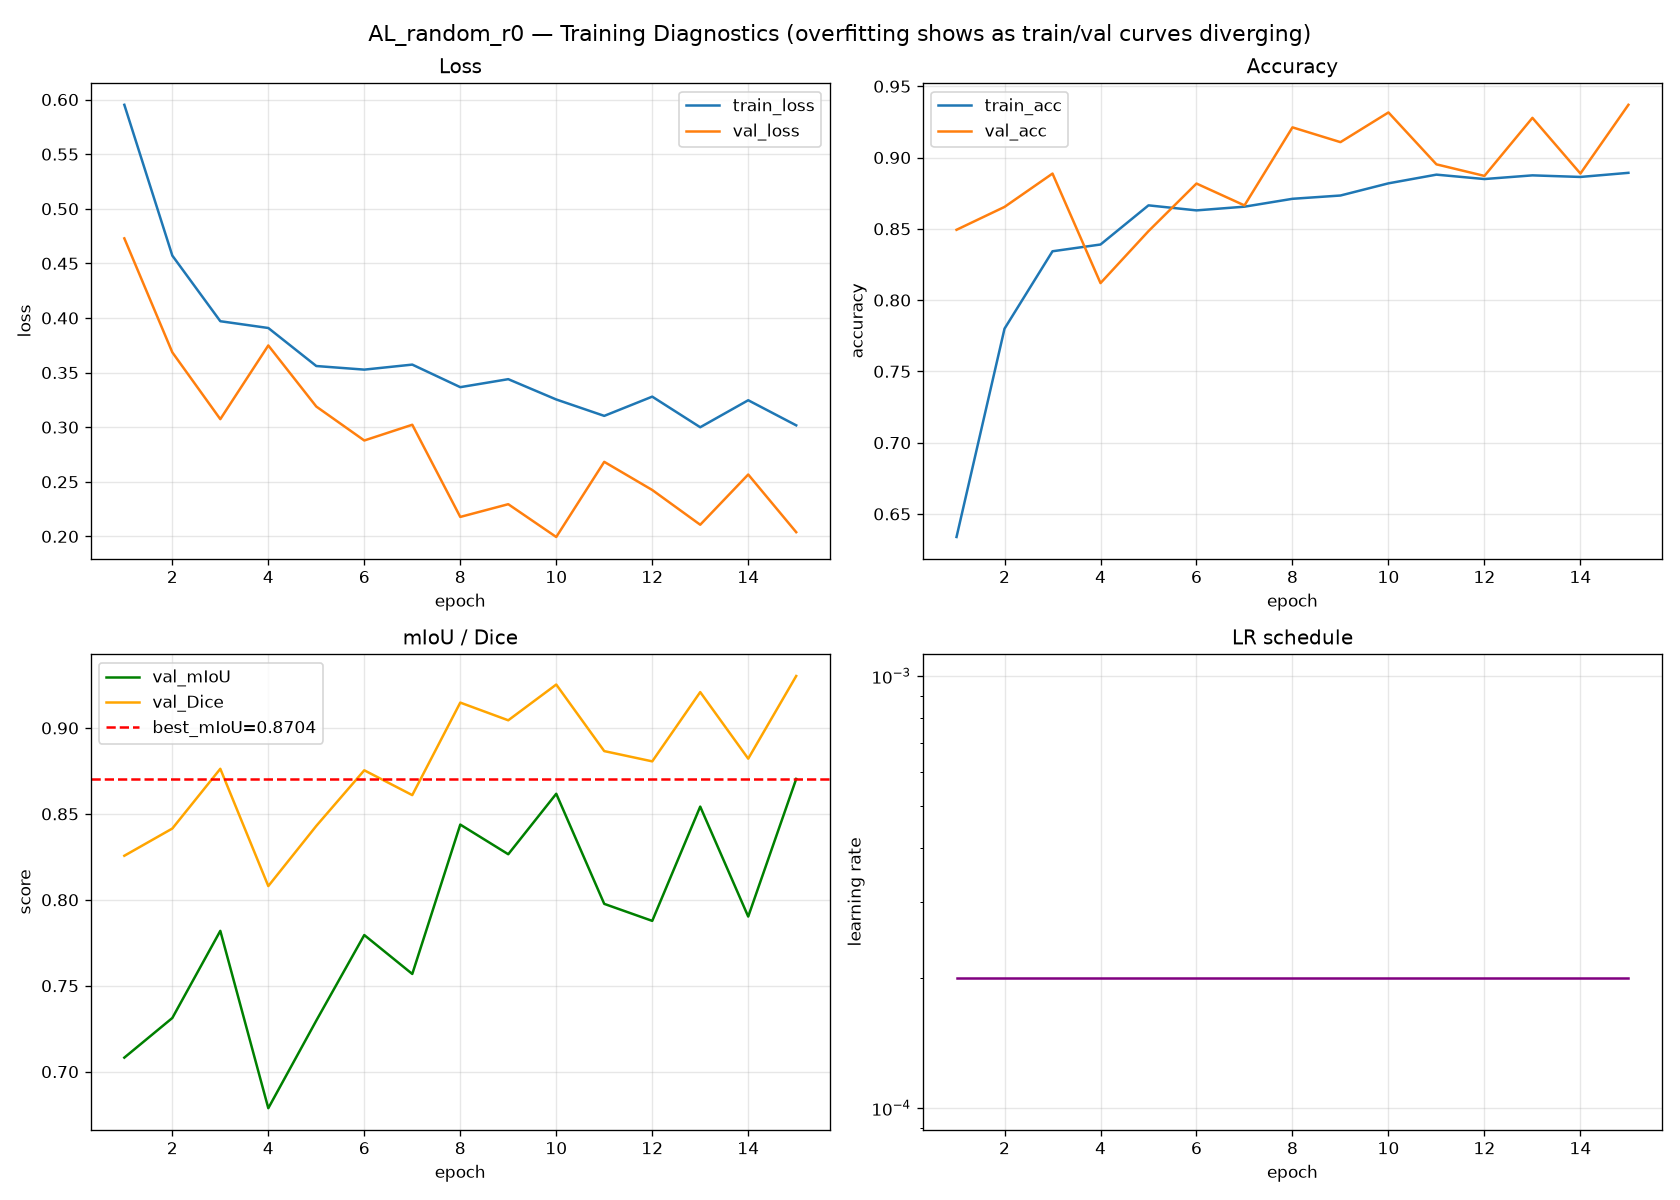

2026-07-24 16:35:21,456 | INFO | Loaded best model (mIoU=0.8704) from checkpoints/PT_v2_17_channel_v57_4_layer_al_AL_random_round0/AL_random_r0_best.pth
2026-07-24 16:35:21,462 | INFO | predict_full_cloud: 416,144 points, N=8,192/chunk, batch=4, device=cuda — this can take a while on CPU, progress below


🏃 View run AL_random_r0_seg at: http://localhost:5000/#/experiments/16/runs/1408e71bf2ab401fb36b6bf230882c9f
🧪 View experiment at: http://localhost:5000/#/experiments/16


2026-07-24 16:35:21,822 | INFO |   flush 1: 32,768/416,144 pts covered (7.9%)
2026-07-24 16:35:22,134 | INFO |   flush 2: 61,392/416,144 pts covered (14.8%)
2026-07-24 16:35:22,427 | INFO |   flush 3: 92,076/416,144 pts covered (22.1%)
2026-07-24 16:35:22,730 | INFO |   flush 4: 119,741/416,144 pts covered (28.8%)
2026-07-24 16:35:23,022 | INFO |   flush 5: 146,779/416,144 pts covered (35.3%)
2026-07-24 16:35:23,315 | INFO |   flush 6: 174,953/416,144 pts covered (42.0%)
2026-07-24 16:35:23,624 | INFO |   flush 7: 201,167/416,144 pts covered (48.3%)
2026-07-24 16:35:23,930 | INFO |   flush 8: 224,175/416,144 pts covered (53.9%)
2026-07-24 16:35:24,221 | INFO |   flush 9: 244,759/416,144 pts covered (58.8%)
2026-07-24 16:35:24,522 | INFO |   flush 10: 265,585/416,144 pts covered (63.8%)
2026-07-24 16:35:24,816 | INFO |   flush 11: 290,717/416,144 pts covered (69.9%)
2026-07-24 16:35:25,110 | INFO |   flush 12: 312,605/416,144 pts covered (75.1%)
2026-07-24 16:35:25,415 | INFO |   flush 

🏃 View run round_00 at: http://localhost:5000/#/experiments/16/runs/b07502b33c0b477ab01cfe4e58e4bda4
🧪 View experiment at: http://localhost:5000/#/experiments/16


2026-07-24 16:36:38,164 | WARNING |   epoch 1: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-24 16:36:50,399 | WARNING |   epoch 1: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-24 16:37:10,463 | WARNING |   epoch 1: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-24 16:37:13,801 | WARNING |   epoch 1: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-24 16:37:17,600 | WARNING |   epoch 1: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-24 16:37:51,624 | INFO |   extra val metrics | Precision: 0.9480 | Recall: 0.6751 | F1: 0.7886 | ROC-AUC: 0.9195 | PR-AUC: 0.9453
2026-07-24 1

...

🏃 View run epoch_0013 at: http://localhost:5000/#/experiments/16/runs/872bf390ab24405e926e837bbba8465c
🧪 View experiment at: http://localhost:5000/#/experiments/16


2026-07-24 16:59:28,562 | INFO |   extra val metrics | Precision: 0.9435 | Recall: 0.9403 | F1: 0.9419 | ROC-AUC: 0.9658 | PR-AUC: 0.9700
2026-07-24 16:59:28,562 | INFO | Epoch  14/15 | Train Loss: 0.2853 | Val Loss: 0.2075 | Train Acc: 0.9070 | Val Acc: 0.9258 | mIoU: 0.8521 | Dice: 0.9197


🏃 View run epoch_0014 at: http://localhost:5000/#/experiments/16/runs/4789dfa88c484337b58ba167ba2bf66a
🧪 View experiment at: http://localhost:5000/#/experiments/16


2026-07-24 17:00:47,610 | WARNING |   epoch 15: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-24 17:01:05,532 | INFO |   extra val metrics | Precision: 0.9189 | Recall: 0.9802 | F1: 0.9486 | ROC-AUC: 0.9655 | PR-AUC: 0.9695
2026-07-24 17:01:05,532 | INFO | Epoch  15/15 | Train Loss: 0.2916 | Val Loss: 0.2351 | Train Acc: 0.9034 | Val Acc: 0.9321 | mIoU: 0.8601 | Dice: 0.9242
2026-07-24 17:01:05,864 | INFO |   💾 Periodic checkpoint saved → checkpoints/PT_v2_17_channel_v57_4_layer_al_AL_random_round1/AL_random_r1_epoch_0015.pth


🏃 View run epoch_0015 at: http://localhost:5000/#/experiments/16/runs/88668a1d989b4476a6efd375b33df6fc
🧪 View experiment at: http://localhost:5000/#/experiments/16


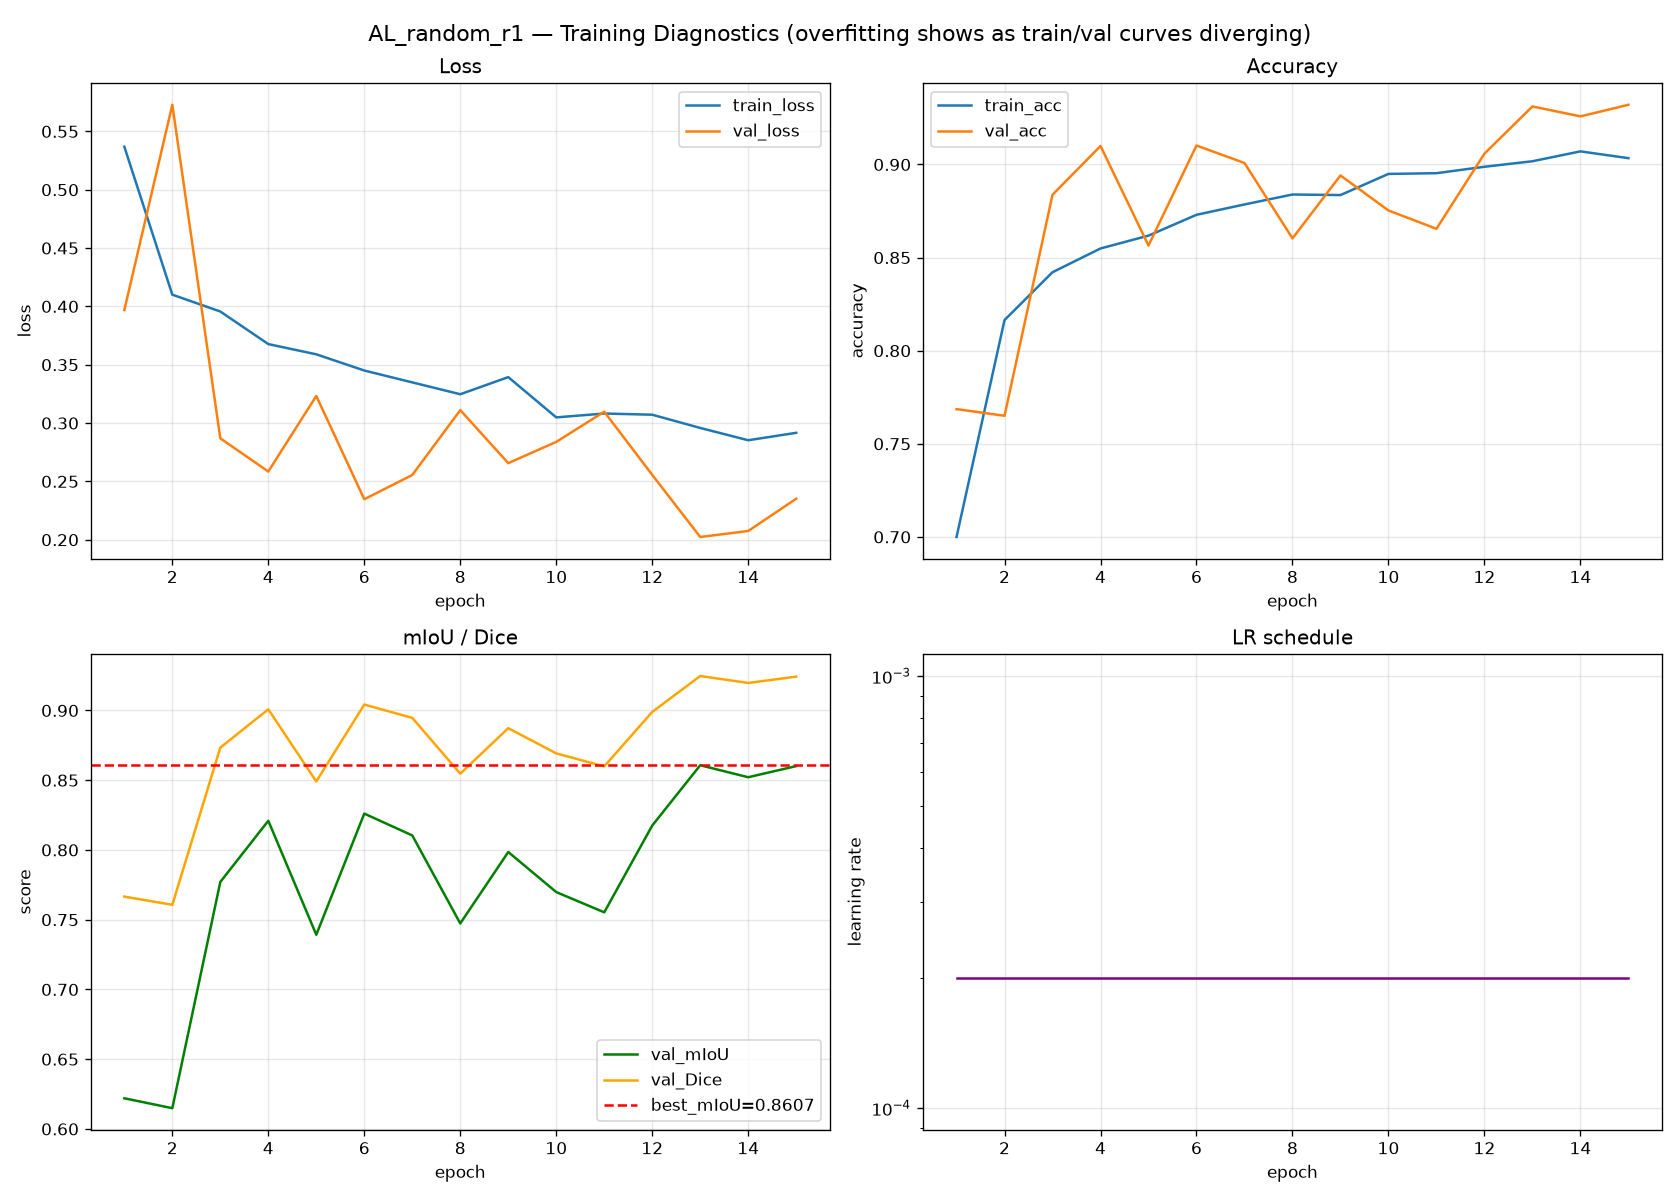

2026-07-24 17:01:06,432 | INFO | Loaded best model (mIoU=0.8607) from checkpoints/PT_v2_17_channel_v57_4_layer_al_AL_random_round1/AL_random_r1_best.pth
2026-07-24 17:01:06,437 | INFO | predict_full_cloud: 416,144 points, N=8,192/chunk, batch=4, device=cuda — this can take a while on CPU, progress below


🏃 View run AL_random_r1_seg at: http://localhost:5000/#/experiments/16/runs/60acbd93fb6d4a7f89a7d09336425cc5
🧪 View experiment at: http://localhost:5000/#/experiments/16


2026-07-24 17:01:06,802 | INFO |   flush 1: 32,768/416,144 pts covered (7.9%)
2026-07-24 17:01:07,088 | INFO |   flush 2: 61,392/416,144 pts covered (14.8%)
2026-07-24 17:01:07,381 | INFO |   flush 3: 92,076/416,144 pts covered (22.1%)
2026-07-24 17:01:07,678 | INFO |   flush 4: 119,741/416,144 pts covered (28.8%)
2026-07-24 17:01:07,976 | INFO |   flush 5: 146,779/416,144 pts covered (35.3%)
2026-07-24 17:01:08,301 | INFO |   flush 6: 174,953/416,144 pts covered (42.0%)
2026-07-24 17:01:08,602 | INFO |   flush 7: 201,167/416,144 pts covered (48.3%)
2026-07-24 17:01:08,914 | INFO |   flush 8: 224,175/416,144 pts covered (53.9%)
2026-07-24 17:01:09,209 | INFO |   flush 9: 244,759/416,144 pts covered (58.8%)
2026-07-24 17:01:09,545 | INFO |   flush 10: 265,585/416,144 pts covered (63.8%)
2026-07-24 17:01:09,842 | INFO |   flush 11: 290,717/416,144 pts covered (69.9%)
2026-07-24 17:01:10,134 | INFO |   flush 12: 312,605/416,144 pts covered (75.1%)
2026-07-24 17:01:10,428 | INFO |   flush 

🏃 View run round_01 at: http://localhost:5000/#/experiments/16/runs/d92d7d609ea54176a4219dac1768af6d
🧪 View experiment at: http://localhost:5000/#/experiments/16


2026-07-24 17:02:09,837 | WARNING |   epoch 1: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-24 17:02:50,276 | WARNING |   epoch 1: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-24 17:03:00,435 | WARNING |   epoch 1: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-24 17:03:32,740 | WARNING |   epoch 1: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-24 17:03:57,007 | INFO |   extra val metrics | Precision: 0.7591 | Recall: 0.9884 | F1: 0.8587 | ROC-AUC: 0.8856 | PR-AUC: 0.8605
2026-07-24 17:03:57,008 | INFO | Epoch   1/15 | Train Loss: 0.4757 | Val Loss: 0.6170 | Train Acc: 0.7631 | Val Acc: 0.8093 | mIoU: 0.6496 | Dice: 0.7828
2026-07-24 17:03:57,335 | IN

...

🏃 View run epoch_0013 at: http://localhost:5000/#/experiments/16/runs/6f2a4340f7344e6697d6676f2d9d7e81
🧪 View experiment at: http://localhost:5000/#/experiments/16


2026-07-24 17:29:58,800 | INFO |   extra val metrics | Precision: 0.9361 | Recall: 0.9502 | F1: 0.9431 | ROC-AUC: 0.9741 | PR-AUC: 0.9776
2026-07-24 17:29:58,801 | INFO | Epoch  14/15 | Train Loss: 0.3033 | Val Loss: 0.1883 | Train Acc: 0.9046 | Val Acc: 0.9328 | mIoU: 0.8703 | Dice: 0.9305


🏃 View run epoch_0014 at: http://localhost:5000/#/experiments/16/runs/226c474e13c54e548e6fa44694c07c90
🧪 View experiment at: http://localhost:5000/#/experiments/16


2026-07-24 17:31:55,586 | INFO |   extra val metrics | Precision: 0.9308 | Recall: 0.9664 | F1: 0.9483 | ROC-AUC: 0.9755 | PR-AUC: 0.9790
2026-07-24 17:31:55,587 | INFO | Epoch  15/15 | Train Loss: 0.2858 | Val Loss: 0.1945 | Train Acc: 0.9082 | Val Acc: 0.9382 | mIoU: 0.8795 | Dice: 0.9357
2026-07-24 17:31:55,918 | INFO |   ✓ New best mIoU 0.8795 → saved checkpoints/PT_v2_17_channel_v57_4_layer_al_AL_random_round2/AL_random_r2_best.pth
2026-07-24 17:31:55,945 | INFO |   💾 Periodic checkpoint saved → checkpoints/PT_v2_17_channel_v57_4_layer_al_AL_random_round2/AL_random_r2_epoch_0015.pth


🏃 View run epoch_0015 at: http://localhost:5000/#/experiments/16/runs/8692239d6c644329b143f238ec8b5f32
🧪 View experiment at: http://localhost:5000/#/experiments/16


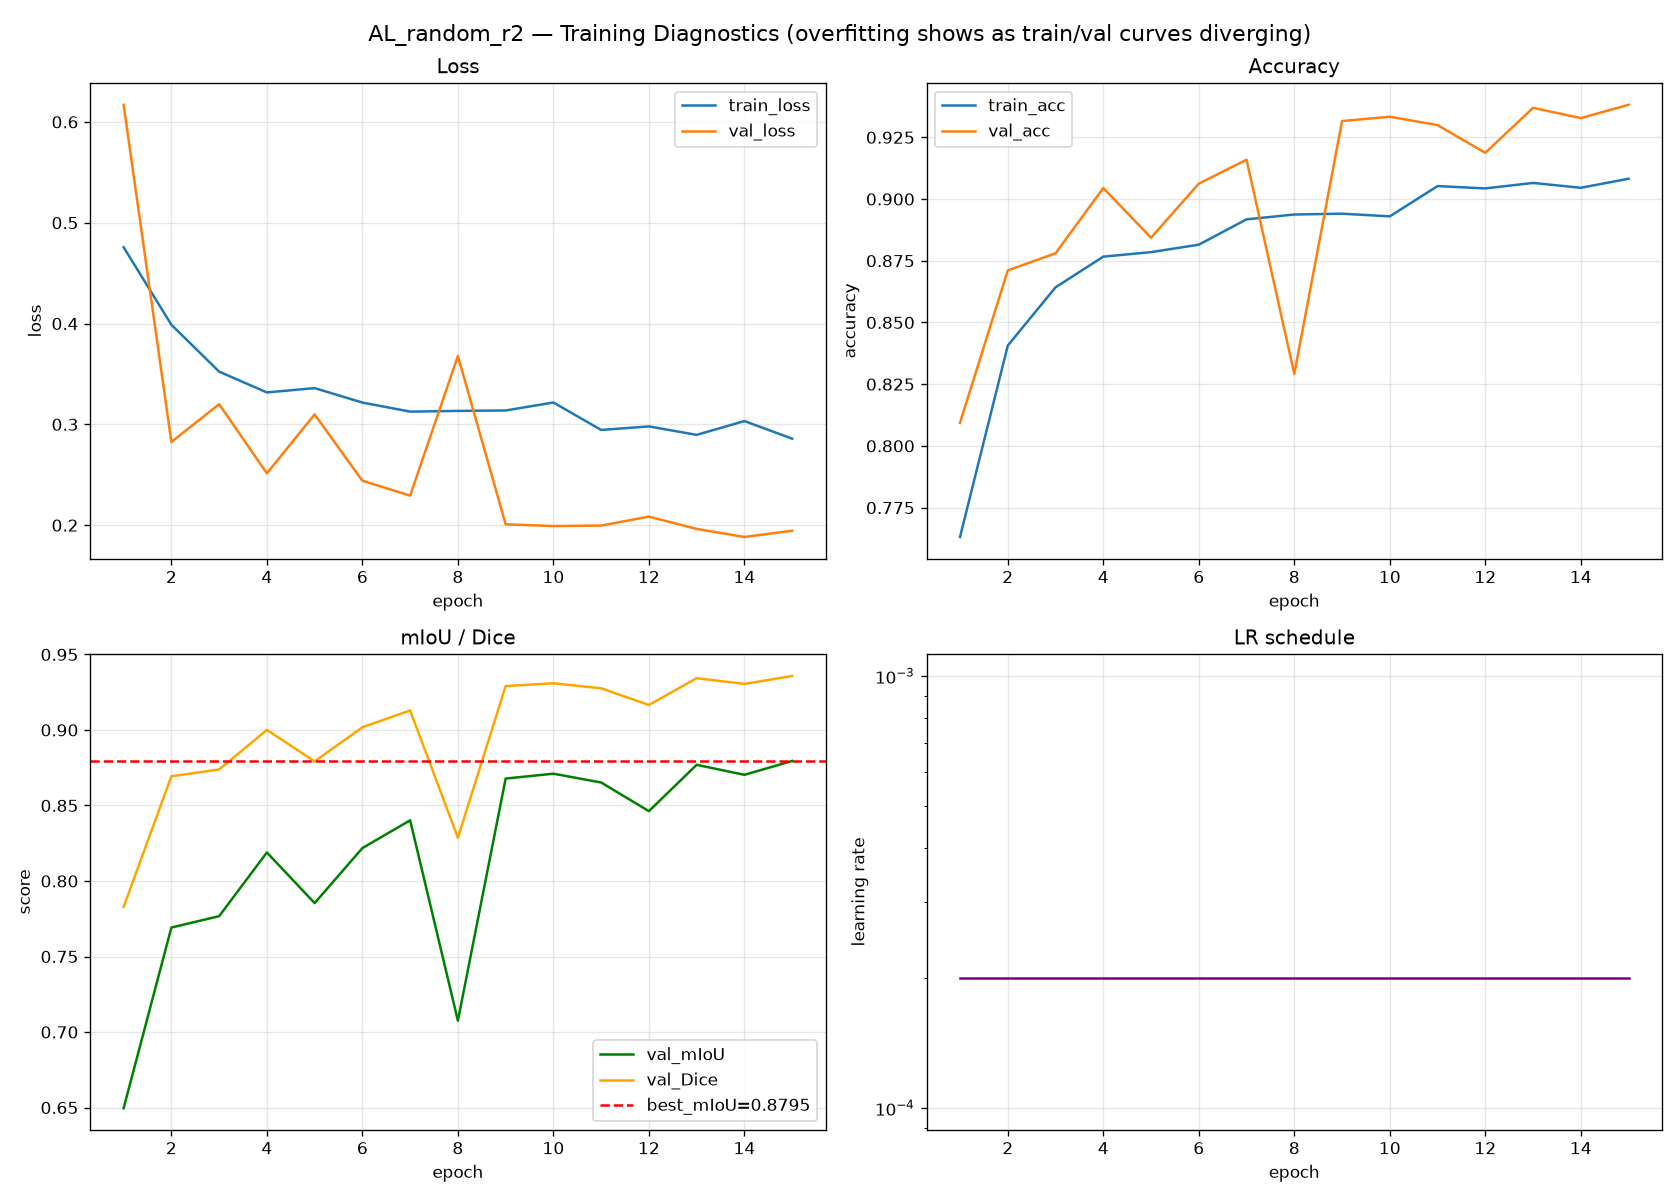

2026-07-24 17:31:56,436 | INFO | Loaded best model (mIoU=0.8795) from checkpoints/PT_v2_17_channel_v57_4_layer_al_AL_random_round2/AL_random_r2_best.pth
2026-07-24 17:31:56,442 | INFO | predict_full_cloud: 416,144 points, N=8,192/chunk, batch=4, device=cuda — this can take a while on CPU, progress below


🏃 View run AL_random_r2_seg at: http://localhost:5000/#/experiments/16/runs/d5621f05c3764336aa97891c6f0a2d03
🧪 View experiment at: http://localhost:5000/#/experiments/16


2026-07-24 17:31:56,798 | INFO |   flush 1: 32,768/416,144 pts covered (7.9%)
2026-07-24 17:31:57,082 | INFO |   flush 2: 61,392/416,144 pts covered (14.8%)
2026-07-24 17:31:57,373 | INFO |   flush 3: 92,076/416,144 pts covered (22.1%)
2026-07-24 17:31:57,680 | INFO |   flush 4: 119,741/416,144 pts covered (28.8%)
2026-07-24 17:31:57,983 | INFO |   flush 5: 146,779/416,144 pts covered (35.3%)
2026-07-24 17:31:58,274 | INFO |   flush 6: 174,953/416,144 pts covered (42.0%)
2026-07-24 17:31:58,568 | INFO |   flush 7: 201,167/416,144 pts covered (48.3%)
2026-07-24 17:31:58,858 | INFO |   flush 8: 224,175/416,144 pts covered (53.9%)
2026-07-24 17:31:59,143 | INFO |   flush 9: 244,759/416,144 pts covered (58.8%)
2026-07-24 17:31:59,447 | INFO |   flush 10: 265,585/416,144 pts covered (63.8%)
2026-07-24 17:31:59,743 | INFO |   flush 11: 290,717/416,144 pts covered (69.9%)
2026-07-24 17:32:00,043 | INFO |   flush 12: 312,605/416,144 pts covered (75.1%)
2026-07-24 17:32:00,343 | INFO |   flush 

🏃 View run round_02 at: http://localhost:5000/#/experiments/16/runs/2e6cd536b1dc4313a046cc3bbc7e6638
🧪 View experiment at: http://localhost:5000/#/experiments/16


2026-07-24 17:32:58,442 | WARNING |   epoch 1: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-24 17:33:08,478 | WARNING |   epoch 1: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-24 17:33:08,994 | WARNING |   epoch 1: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-24 17:34:08,420 | WARNING |   epoch 1: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-24 17:34:09,461 | WARNING |   epoch 1: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-24 17:35:09,802 | INFO |   extra val metrics | Precision: 0.9630 | Recall: 0.7119 | F1: 0.8186 | ROC-AUC: 0.9262 | PR-AUC: 0.9466
2026-07-24 1

...

🏃 View run epoch_0013 at: http://localhost:5000/#/experiments/16/runs/dbfcb4abca0149508604093fa0b88a4c
🧪 View experiment at: http://localhost:5000/#/experiments/16


2026-07-24 18:05:23,017 | INFO |   extra val metrics | Precision: 0.9213 | Recall: 0.9819 | F1: 0.9506 | ROC-AUC: 0.9801 | PR-AUC: 0.9816
2026-07-24 18:05:23,017 | INFO | Epoch  14/15 | Train Loss: 0.2582 | Val Loss: 0.1864 | Train Acc: 0.9202 | Val Acc: 0.9402 | mIoU: 0.8826 | Dice: 0.9374


🏃 View run epoch_0014 at: http://localhost:5000/#/experiments/16/runs/ec58e625c94a40cba20c2cac875fc727
🧪 View experiment at: http://localhost:5000/#/experiments/16


2026-07-24 18:07:46,075 | INFO |   extra val metrics | Precision: 0.9370 | Recall: 0.9753 | F1: 0.9558 | ROC-AUC: 0.9791 | PR-AUC: 0.9811
2026-07-24 18:07:46,076 | INFO | Epoch  15/15 | Train Loss: 0.2555 | Val Loss: 0.1736 | Train Acc: 0.9195 | Val Acc: 0.9471 | mIoU: 0.8958 | Dice: 0.9449
2026-07-24 18:07:46,446 | INFO |   ✓ New best mIoU 0.8958 → saved checkpoints/PT_v2_17_channel_v57_4_layer_al_AL_random_round3/AL_random_r3_best.pth
2026-07-24 18:07:46,473 | INFO |   💾 Periodic checkpoint saved → checkpoints/PT_v2_17_channel_v57_4_layer_al_AL_random_round3/AL_random_r3_epoch_0015.pth


🏃 View run epoch_0015 at: http://localhost:5000/#/experiments/16/runs/03573f0c3ac841a98cea47db7ab8009a
🧪 View experiment at: http://localhost:5000/#/experiments/16


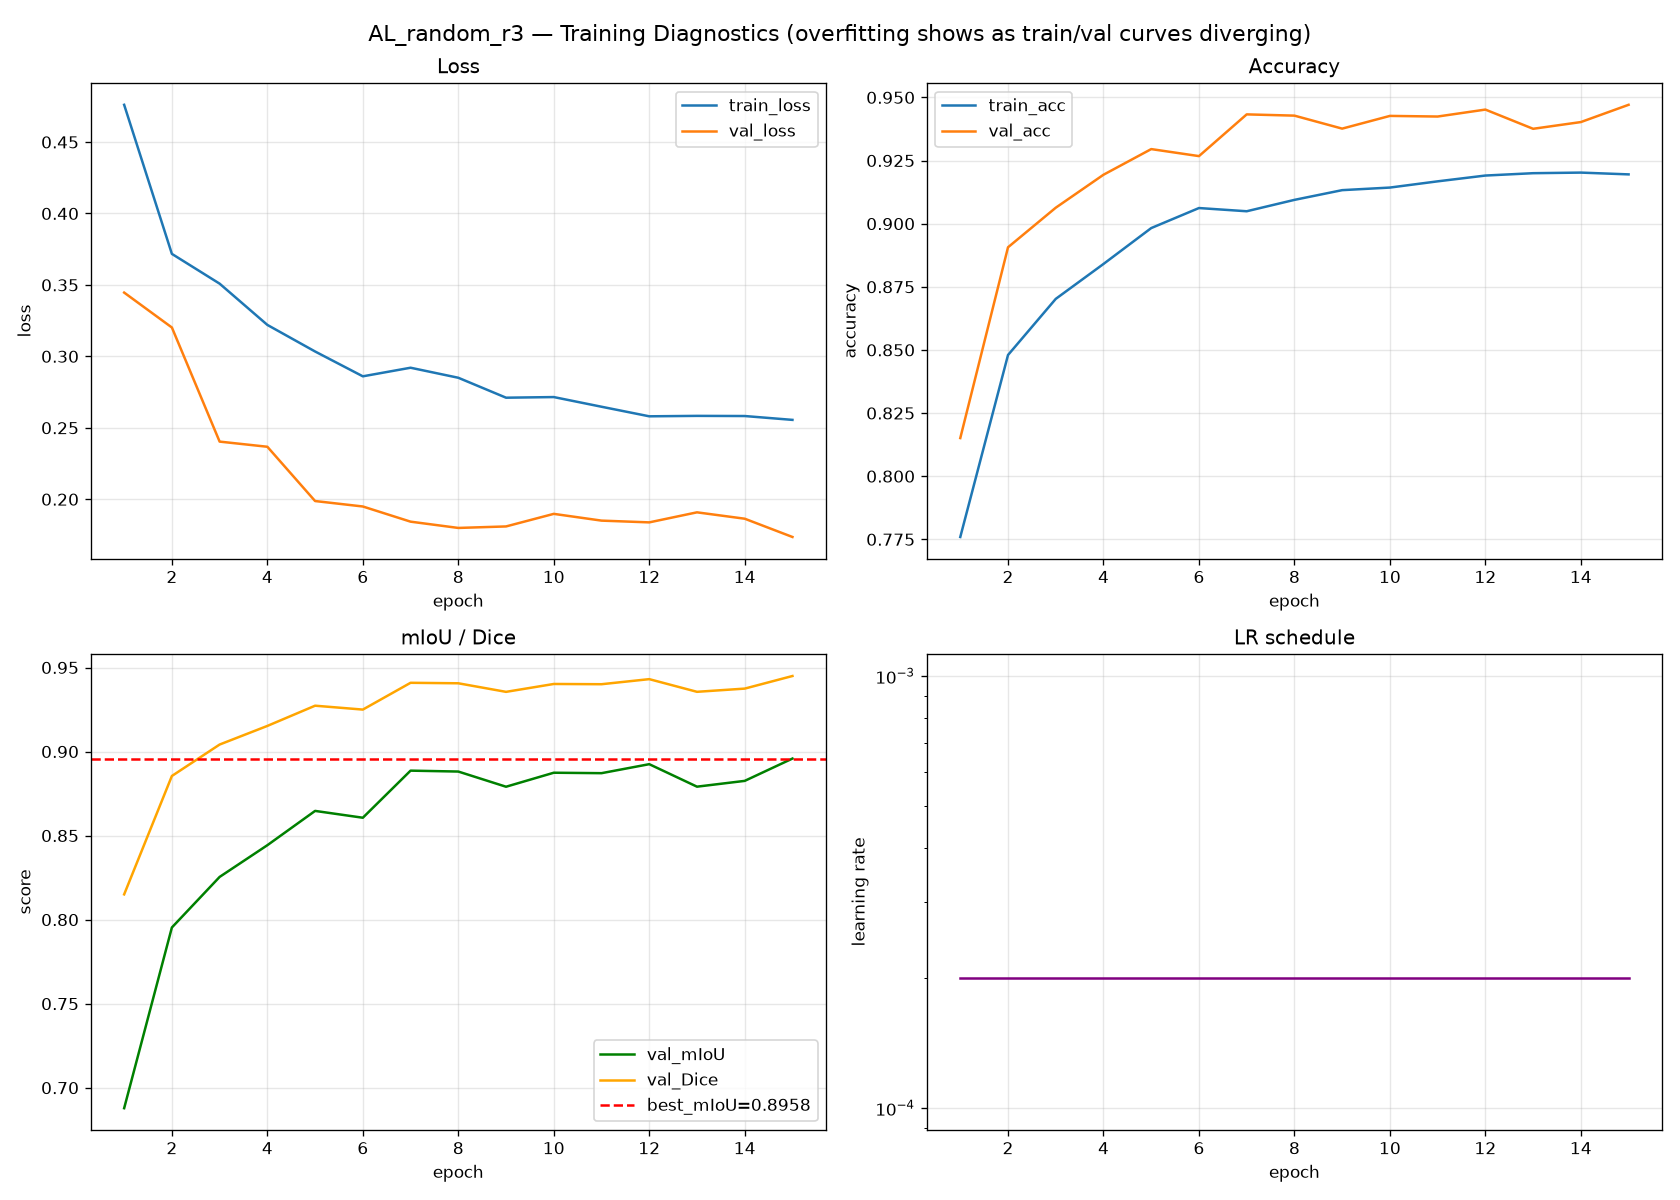

2026-07-24 18:07:47,031 | INFO | Loaded best model (mIoU=0.8958) from checkpoints/PT_v2_17_channel_v57_4_layer_al_AL_random_round3/AL_random_r3_best.pth
2026-07-24 18:07:47,037 | INFO | predict_full_cloud: 416,144 points, N=8,192/chunk, batch=4, device=cuda — this can take a while on CPU, progress below


🏃 View run AL_random_r3_seg at: http://localhost:5000/#/experiments/16/runs/d58f77ab144041c68ca7b1ca18360e49
🧪 View experiment at: http://localhost:5000/#/experiments/16


2026-07-24 18:07:47,407 | INFO |   flush 1: 32,768/416,144 pts covered (7.9%)
2026-07-24 18:07:47,695 | INFO |   flush 2: 61,392/416,144 pts covered (14.8%)
2026-07-24 18:07:47,998 | INFO |   flush 3: 92,076/416,144 pts covered (22.1%)
2026-07-24 18:07:48,290 | INFO |   flush 4: 119,741/416,144 pts covered (28.8%)
2026-07-24 18:07:48,592 | INFO |   flush 5: 146,779/416,144 pts covered (35.3%)
2026-07-24 18:07:48,888 | INFO |   flush 6: 174,953/416,144 pts covered (42.0%)
2026-07-24 18:07:49,183 | INFO |   flush 7: 201,167/416,144 pts covered (48.3%)
2026-07-24 18:07:49,472 | INFO |   flush 8: 224,175/416,144 pts covered (53.9%)
2026-07-24 18:07:49,760 | INFO |   flush 9: 244,759/416,144 pts covered (58.8%)
2026-07-24 18:07:50,082 | INFO |   flush 10: 265,585/416,144 pts covered (63.8%)
2026-07-24 18:07:50,368 | INFO |   flush 11: 290,717/416,144 pts covered (69.9%)
2026-07-24 18:07:50,657 | INFO |   flush 12: 312,605/416,144 pts covered (75.1%)
2026-07-24 18:07:50,944 | INFO |   flush 

🏃 View run round_03 at: http://localhost:5000/#/experiments/16/runs/fd6ea703b172457a95f7d54a77ab294f
🧪 View experiment at: http://localhost:5000/#/experiments/16


2026-07-24 18:09:11,535 | WARNING |   epoch 1: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-24 18:09:15,743 | WARNING |   epoch 1: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-24 18:10:54,159 | WARNING |   epoch 1: NaN/Inf gradient detected — GradScaler will automatically skip the real parameter update for this step (weights protected)
2026-07-24 18:12:01,639 | INFO |   extra val metrics | Precision: 0.8963 | Recall: 0.8021 | F1: 0.8466 | ROC-AUC: 0.9300 | PR-AUC: 0.9487
2026-07-24 18:12:01,640 | INFO | Epoch   1/15 | Train Loss: 0.5062 | Val Loss: 0.3588 | Train Acc: 0.7466 | Val Acc: 0.8248 | mIoU: 0.6974 | Dice: 0.8212
2026-07-24 18:12:01,991 | INFO |   ✓ New best mIoU 0.6974 → saved checkpoints/PT_v2_17_channel_v57_4_layer_al_AL_random_round4/AL_random_r4_best.pth


...

🏃 View run epoch_0013 at: http://localhost:5000/#/experiments/16/runs/7ff294b826894a7ea21f919b9cf8f41b
🧪 View experiment at: http://localhost:5000/#/experiments/16


2026-07-24 18:47:34,971 | INFO |   extra val metrics | Precision: 0.9407 | Recall: 0.9615 | F1: 0.9510 | ROC-AUC: 0.9781 | PR-AUC: 0.9832
2026-07-24 18:47:34,971 | INFO | Epoch  14/15 | Train Loss: 0.2505 | Val Loss: 0.1796 | Train Acc: 0.9228 | Val Acc: 0.9403 | mIoU: 0.8822 | Dice: 0.9373
2026-07-24 18:47:35,319 | INFO |   ✓ New best mIoU 0.8822 → saved checkpoints/PT_v2_17_channel_v57_4_layer_al_AL_random_round4/AL_random_r4_best.pth


🏃 View run epoch_0014 at: http://localhost:5000/#/experiments/16/runs/43ce7bb2c9e04853a333c31b401d613d
🧪 View experiment at: http://localhost:5000/#/experiments/16


2026-07-24 18:50:15,416 | INFO |   extra val metrics | Precision: 0.9415 | Recall: 0.9619 | F1: 0.9516 | ROC-AUC: 0.9757 | PR-AUC: 0.9808
2026-07-24 18:50:15,417 | INFO | Epoch  15/15 | Train Loss: 0.2486 | Val Loss: 0.1897 | Train Acc: 0.9244 | Val Acc: 0.9410 | mIoU: 0.8836 | Dice: 0.9380
2026-07-24 18:50:15,733 | INFO |   ✓ New best mIoU 0.8836 → saved checkpoints/PT_v2_17_channel_v57_4_layer_al_AL_random_round4/AL_random_r4_best.pth
2026-07-24 18:50:15,758 | INFO |   💾 Periodic checkpoint saved → checkpoints/PT_v2_17_channel_v57_4_layer_al_AL_random_round4/AL_random_r4_epoch_0015.pth


🏃 View run epoch_0015 at: http://localhost:5000/#/experiments/16/runs/dd55a091a0f14026a38979fa88c22363
🧪 View experiment at: http://localhost:5000/#/experiments/16


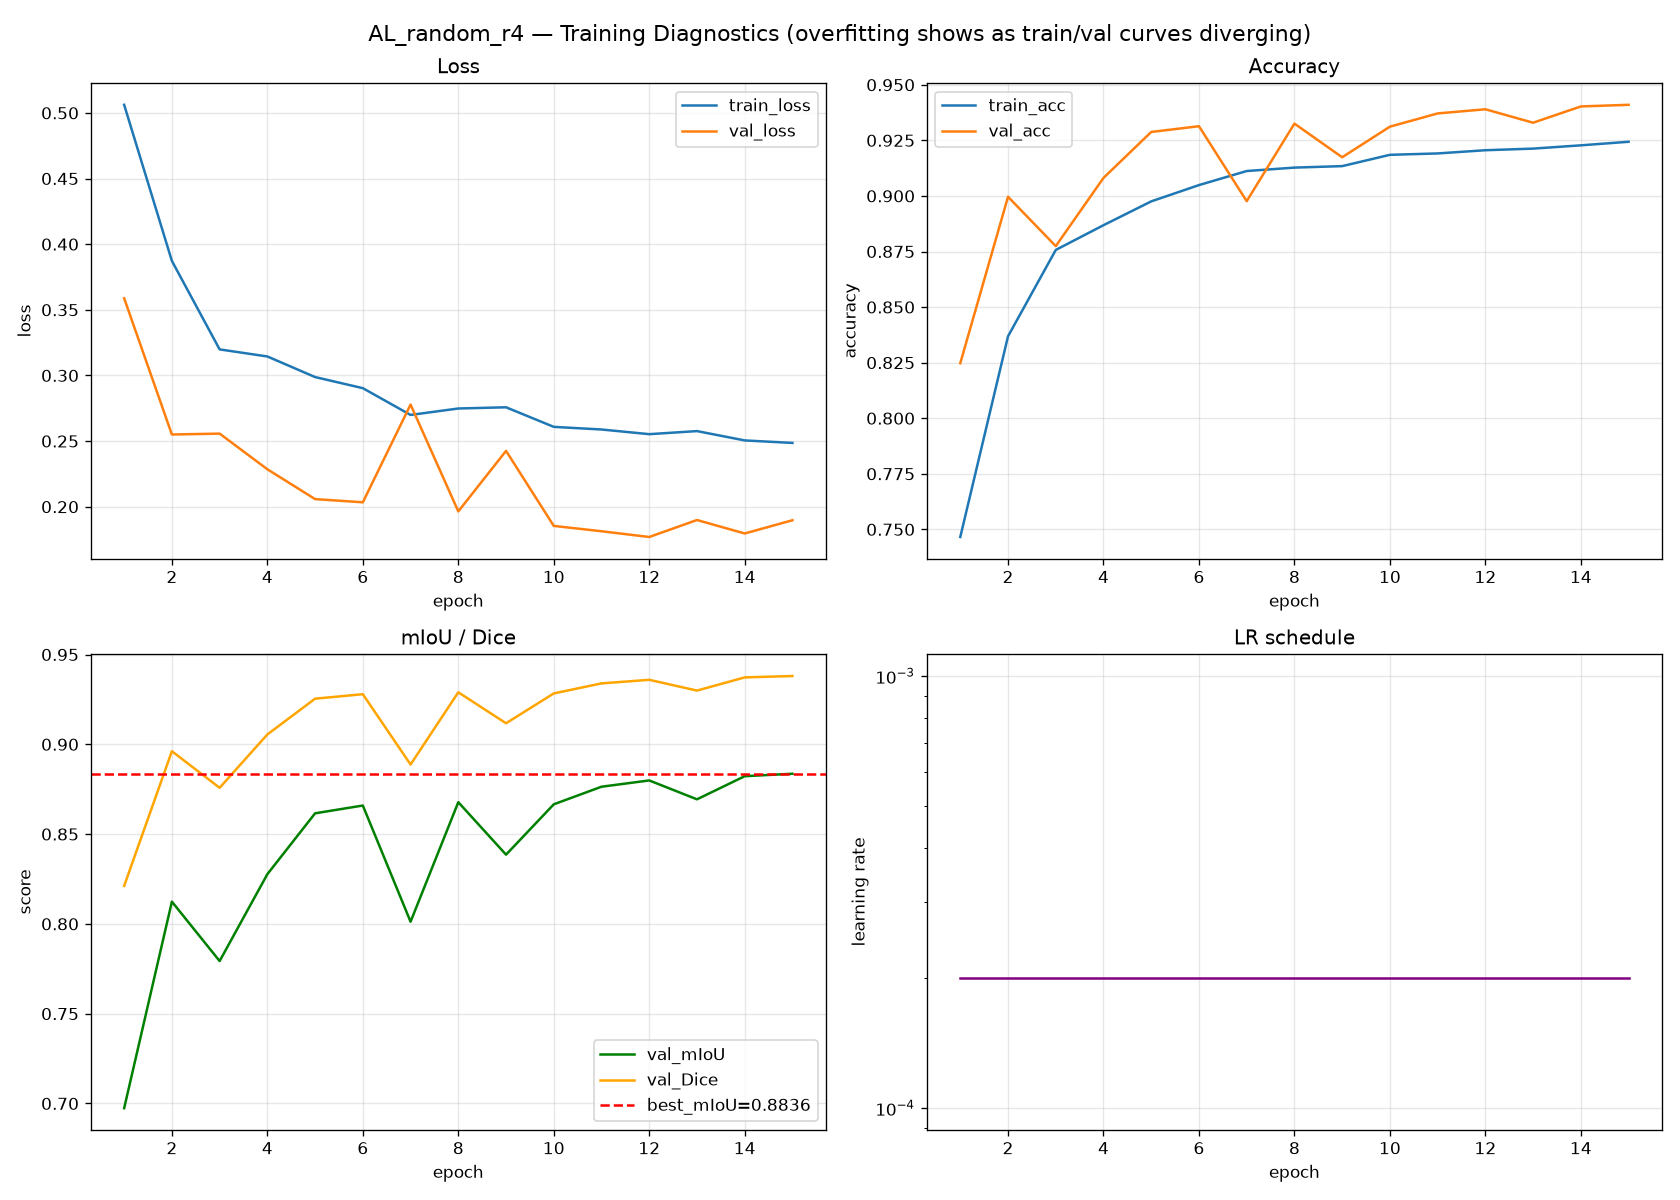

2026-07-24 18:50:16,366 | INFO | Loaded best model (mIoU=0.8836) from checkpoints/PT_v2_17_channel_v57_4_layer_al_AL_random_round4/AL_random_r4_best.pth
2026-07-24 18:50:16,372 | INFO | predict_full_cloud: 416,144 points, N=8,192/chunk, batch=4, device=cuda — this can take a while on CPU, progress below


🏃 View run AL_random_r4_seg at: http://localhost:5000/#/experiments/16/runs/3d29202d4cb8488a935f4dc2ca70b1c8
🧪 View experiment at: http://localhost:5000/#/experiments/16


2026-07-24 18:50:16,728 | INFO |   flush 1: 32,768/416,144 pts covered (7.9%)
2026-07-24 18:50:17,016 | INFO |   flush 2: 61,392/416,144 pts covered (14.8%)
2026-07-24 18:50:17,304 | INFO |   flush 3: 92,076/416,144 pts covered (22.1%)
2026-07-24 18:50:17,601 | INFO |   flush 4: 119,741/416,144 pts covered (28.8%)
2026-07-24 18:50:17,900 | INFO |   flush 5: 146,779/416,144 pts covered (35.3%)
2026-07-24 18:50:18,189 | INFO |   flush 6: 174,953/416,144 pts covered (42.0%)
2026-07-24 18:50:18,480 | INFO |   flush 7: 201,167/416,144 pts covered (48.3%)
2026-07-24 18:50:18,767 | INFO |   flush 8: 224,175/416,144 pts covered (53.9%)
2026-07-24 18:50:19,059 | INFO |   flush 9: 244,759/416,144 pts covered (58.8%)
2026-07-24 18:50:19,356 | INFO |   flush 10: 265,585/416,144 pts covered (63.8%)
2026-07-24 18:50:19,643 | INFO |   flush 11: 290,717/416,144 pts covered (69.9%)
2026-07-24 18:50:19,927 | INFO |   flush 12: 312,605/416,144 pts covered (75.1%)
2026-07-24 18:50:20,219 | INFO |   flush 

🏃 View run round_04 at: http://localhost:5000/#/experiments/16/runs/bdc941788f8749e898bd19f0b22cc26b
🧪 View experiment at: http://localhost:5000/#/experiments/16
🏃 View run AL_random at: http://localhost:5000/#/experiments/16/runs/b4cae9ad835f4f1dbc668f93a9bbb6a8
🧪 View experiment at: http://localhost:5000/#/experiments/16


/tmp/ipykernel_9033/1674189260.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


🏃 View run AL_comparison_summary at: http://localhost:5000/#/experiments/16/runs/59565defc8b3411a88a55cfd43f3fff1
🧪 View experiment at: http://localhost:5000/#/experiments/16


In [21]:
# Run both arms of the comparison. Each call fully retrains from scratch
# per round, so this is the expensive cell -- lower CONFIG["al_rounds"] /
# CONFIG["al_round_epochs"] first if you just want a smoke test.
if CONFIG.get("al_enabled", False):
    al_history_active = run_active_learning_experiment(strategy="active")
    al_history_random = run_active_learning_experiment(strategy="random")

    import pandas as pd
    _df_active = pd.DataFrame(al_history_active)
    _df_random = pd.DataFrame(al_history_random)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(_df_active["n_labeled"], _df_active["test_miou"],
           marker="o", label="active (MC-Dropout)")
    ax.plot(_df_random["n_labeled"], _df_random["test_miou"],
           marker="o", label="random baseline")
    ax.set_xlabel("labeled files"); ax.set_ylabel("test mIoU")
    ax.set_title("Active Learning vs Random: data-efficiency comparison")
    ax.legend(); ax.grid(alpha=0.3)
    _al_plot_path = os.path.join(CONFIG["checkpoint_dir"], "al_comparison.png")
    os.makedirs(CONFIG["checkpoint_dir"], exist_ok=True)
    plt.savefig(_al_plot_path, dpi=120)
    plt.show()

    if MLFLOW_OK:
        mlflow.set_experiment(CONFIG.get("al_mlflow_experiment", "PT_v2_active_learning"))
        with mlflow.start_run(run_name="AL_comparison_summary"):
            mlflow.log_artifact(_al_plot_path)
            for _, r in _df_active.iterrows():
                mlflow.log_metric("active_test_miou", r["test_miou"], step=int(r["n_labeled"]))
            for _, r in _df_random.iterrows():
                mlflow.log_metric("random_test_miou", r["test_miou"], step=int(r["n_labeled"]))
else:
    log.info("CONFIG['al_enabled'] is False -- skipping active learning experiment.")


In [22]:
# ── Save a consolidated, clearly-named copy of the overall-best checkpoint ──
# (only relevant when K-fold CV was used above; safe to skip otherwise)
if CV_FOLDS is not None:
    overall_best_path = f"{_base_ckpt_dir}_BEST_OVERALL.pth"
    state["source_fold"] = best_fold
    state["source_fold_miou"] = float(fold_mious[best_fold])
    state["all_fold_mious"] = fold_mious.tolist()
    torch.save(state, overall_best_path)
    log.info(f"  Saved consolidated best-overall checkpoint -> {overall_best_path} "
             f"(from fold {best_fold + 1}, mIoU={fold_mious[best_fold]:.4f})")
else:
    log.info("  CV_FOLDS is None (single training run) — no consolidated "
             "best-overall checkpoint needed; use the run's own best.pth")

2026-07-24 18:51:10,541 | INFO |   CV_FOLDS is None (single training run) — no consolidated best-overall checkpoint needed; use the run's own best.pth


## Per-file Train/Val Report (log only, no saving)

In [23]:
log.info("=== TRAIN/VAL PER-FILE REPORT ===")
trval_names, trval_true, trval_pred = [], [], []
for path in TRAIN_FILES:
    name = os.path.splitext(os.path.basename(path))[0]
    pts, preds, lbl = predict_full_cloud(model, path)
    trval_names.append(f"{name} [train]"); trval_true.append(lbl); trval_pred.append(preds)
per_file_report(trval_names, trval_true, trval_pred, tag="TRAIN",
                target_class=CONFIG["target_class"])
val_names, val_true, val_pred = [], [], []
for path in VAL_FILES:
    name = os.path.splitext(os.path.basename(path))[0]
    pts, preds, lbl = predict_full_cloud(model, path)
    val_names.append(f"{name} [val]"); val_true.append(lbl); val_pred.append(preds)
per_file_report(val_names, val_true, val_pred, tag="VAL",
                target_class=CONFIG["target_class"])

2026-07-24 18:51:10,557 | INFO | === TRAIN/VAL PER-FILE REPORT ===
2026-07-24 18:51:10,559 | INFO | predict_full_cloud: 296,835 points, N=8,192/chunk, batch=4, device=cuda — this can take a while on CPU, progress below
2026-07-24 18:51:10,916 | INFO |   flush 1: 32,444/296,835 pts covered (10.9%)
2026-07-24 18:51:11,220 | INFO |   flush 2: 63,880/296,835 pts covered (21.5%)
2026-07-24 18:51:11,522 | INFO |   flush 3: 88,346/296,835 pts covered (29.8%)
2026-07-24 18:51:11,800 | INFO |   flush 4: 121,030/296,835 pts covered (40.8%)
2026-07-24 18:51:12,100 | INFO |   flush 5: 147,300/296,835 pts covered (49.6%)
2026-07-24 18:51:12,380 | INFO |   flush 6: 172,717/296,835 pts covered (58.2%)
2026-07-24 18:51:12,670 | INFO |   flush 7: 190,402/296,835 pts covered (64.1%)
2026-07-24 18:51:12,967 | INFO |   flush 8: 211,443/296,835 pts covered (71.2%)
2026-07-24 18:51:13,274 | INFO |   flush 9: 226,009/296,835 pts covered (76.1%)
2026-07-24 18:51:13,550 | INFO |   flush 10: 238,080/296,835 pts


PER-FILE SEGMENTATION REPORT — TRAIN
File                      IoU   Dice   Prec    Rec       TP       FP       FN       TN   GT_Wood  Pred_Wood
-----------------------------------------------------------------------------------------------------------
sample_data_0039 [train]  0.000  0.000  0.000  0.000        0        0  211,210   85,625   211,210          0
sample_data_0027 [train]  0.000  0.000  0.000  0.000        0        0  256,513  193,516   256,513          0
sample_data_0025 [train]  0.000  0.000  0.000  0.000        0        0  174,809  107,254   174,809          0
sample_data_0021 [train]  0.000  0.000  0.000  0.000        0        0  192,944  162,330   192,944          0
sample_data_007 [train]  0.000  0.000  0.000  0.000        0        0  265,815  130,243   265,815          0
sample_data_0023 [train]  0.000  0.000  0.000  0.000        0        0  258,972  209,996   258,972          0
sample_data_0018 [train]  0.000  0.000  0.000  0.000        0        0  259,985  184,80

2026-07-24 18:55:35,643 | INFO |   flush 1: 31,375/311,676 pts covered (10.1%)
2026-07-24 18:55:35,943 | INFO |   flush 2: 59,617/311,676 pts covered (19.1%)
2026-07-24 18:55:36,238 | INFO |   flush 3: 90,009/311,676 pts covered (28.9%)
2026-07-24 18:55:36,549 | INFO |   flush 4: 122,424/311,676 pts covered (39.3%)
2026-07-24 18:55:36,844 | INFO |   flush 5: 151,607/311,676 pts covered (48.6%)
2026-07-24 18:55:37,149 | INFO |   flush 6: 174,716/311,676 pts covered (56.1%)
2026-07-24 18:55:37,444 | INFO |   flush 7: 192,645/311,676 pts covered (61.8%)
2026-07-24 18:55:37,759 | INFO |   flush 8: 217,021/311,676 pts covered (69.6%)
2026-07-24 18:55:38,052 | INFO |   flush 9: 239,811/311,676 pts covered (76.9%)
2026-07-24 18:55:38,350 | INFO |   flush 10: 248,840/311,676 pts covered (79.8%)
2026-07-24 18:55:38,652 | INFO |   flush 11: 261,811/311,676 pts covered (84.0%)
2026-07-24 18:55:38,968 | INFO |   flush 12: 279,832/311,676 pts covered (89.8%)
2026-07-24 18:55:39,267 | INFO |   flush


PER-FILE SEGMENTATION REPORT — VAL
File                      IoU   Dice   Prec    Rec       TP       FP       FN       TN   GT_Wood  Pred_Wood
-----------------------------------------------------------------------------------------------------------
sample_data_0013 [val]  0.000  0.000  0.000  0.000        0        0  208,367  103,309   208,367          0
sample_data_0020 [val]  0.000  0.000  0.000  0.000        0        0  284,743  135,833   284,743          0
sample_data_0017 [val]  0.000  0.000  0.000  0.000        0        0  387,124  169,275   387,124          0
sample_data_0012 [val]  0.000  0.000  0.000  0.000        0        0  240,600  159,605   240,600          0
sample_data_0015 [val]  0.000  0.000  0.000  0.000        0        0  278,614  112,754   278,614          0
sample_data_0031 [val]  0.000  0.000  0.000  0.000        0        0  205,704   30,635   205,704          0
----------------------------------------------------------------------------------------------------

In [24]:
from scipy.spatial import Delaunay, cKDTree
def sor_filter(pts, k=16, std_ratio=2.0):
    pts = np.asarray(pts, np.float64)
    if len(pts) <= k + 1:
        return pts, np.ones(len(pts), bool)
    tree = cKDTree(pts)
    d, _ = tree.query(pts, k=k + 1)
    mean_dist = d[:, 1:].mean(axis=1)
    thr  = mean_dist.mean() + std_ratio * mean_dist.std()
    mask = mean_dist <= thr
    return pts[mask], mask
def extract_main_cluster(pts, eps=0.15, min_samples=8):
    pts = np.asarray(pts, np.float64)
    if len(pts) < min_samples * 2:
        return pts
    try:
        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(pts)
        labels = np.asarray(pcd.cluster_dbscan(eps=eps, min_points=min_samples))
        valid = labels[labels >= 0]
        if valid.size == 0:
            return pts
        main_lbl = np.bincount(valid).argmax()
        result = pts[labels == main_lbl]
        return result if len(result) >= min_samples else pts
    except Exception as e:
        log.warning(f"[TIN] cluster extraction failed ({e}) -> using all points")
        return pts
def tin_integrate(pts, floor_pct=0.5):
    pts = np.asarray(pts, np.float64)
    if len(pts) < 4:
        return float("nan")
    floor_z = np.percentile(pts[:, 2], floor_pct)
    h  = pts[:, 2] - floor_z
    xy = pts[:, :2]
    try:
        tri = Delaunay(xy)
    except Exception as e:
        log.warning(f"[TIN] Delaunay failed ({e})")
        return float("nan")
    t = tri.simplices
    p0, p1, p2 = xy[t[:, 0]], xy[t[:, 1]], xy[t[:, 2]]
    h0, h1, h2 = h[t[:, 0]], h[t[:, 1]], h[t[:, 2]]
    cross  = ((p1[:, 0] - p0[:, 0]) * (p2[:, 1] - p0[:, 1])
             - (p1[:, 1] - p0[:, 1]) * (p2[:, 0] - p0[:, 0]))
    area2d = np.abs(cross) / 2.0
    mean_h = (h0 + h1 + h2) / 3.0
    valid  = mean_h > 0
    return float(np.sum(area2d[valid] * mean_h[valid]))
def bootstrap_tin_confidence(pts, n_bootstrap=80, subsample_frac=0.85,
                             floor_pct=0.5, seed=0):
    rng = np.random.RandomState(seed)
    n = len(pts)
    n_sub = max(10, int(n * subsample_frac))
    estimates = []
    for _ in range(n_bootstrap):
        idx = rng.choice(n, n_sub, replace=False)
        v = tin_integrate(pts[idx], floor_pct=floor_pct)
        if np.isfinite(v) and v > 0:
            estimates.append(v)
    if len(estimates) < 5:
        return None
    arr = np.array(estimates)
    return {"std":     round(float(arr.std()), 5),
            "ci_low":  round(float(np.percentile(arr, 2.5)), 5),
            "ci_high": round(float(np.percentile(arr, 97.5)), 5)}
def vol_TIN(pts, sor_k=16, sor_std=2.0, cluster_eps=0.15,
            floor_pct=0.5, run_bootstrap=True, n_bootstrap=80):
    pts = np.asarray(pts, np.float64)
    if len(pts) < 10:
        return float("nan"), None
    pts, _ = sor_filter(pts, k=sor_k, std_ratio=sor_std)
    if len(pts) < 10:
        return float("nan"), None
    pts = extract_main_cluster(pts, eps=cluster_eps)
    if len(pts) < 10:
        return float("nan"), None
    volume = tin_integrate(pts, floor_pct=floor_pct)
    conf = None
    if run_bootstrap and len(pts) >= 20:
        conf = bootstrap_tin_confidence(pts, n_bootstrap=n_bootstrap,
                                        floor_pct=floor_pct)
    return float(volume), conf

## Testing  (held-out test files with labels)

2026-07-24 18:56:21,451 | INFO | === TESTING ===
2026-07-24 18:56:21,452 | INFO | predict_full_cloud: 416,144 points, N=8,192/chunk, batch=4, device=cuda — this can take a while on CPU, progress below
2026-07-24 18:56:21,837 | INFO |   flush 1: 32,768/416,144 pts covered (7.9%)
2026-07-24 18:56:22,122 | INFO |   flush 2: 61,392/416,144 pts covered (14.8%)
2026-07-24 18:56:22,411 | INFO |   flush 3: 92,076/416,144 pts covered (22.1%)
2026-07-24 18:56:22,711 | INFO |   flush 4: 119,741/416,144 pts covered (28.8%)
2026-07-24 18:56:23,027 | INFO |   flush 5: 146,779/416,144 pts covered (35.3%)
2026-07-24 18:56:23,324 | INFO |   flush 6: 174,953/416,144 pts covered (42.0%)
2026-07-24 18:56:23,621 | INFO |   flush 7: 201,167/416,144 pts covered (48.3%)
2026-07-24 18:56:23,915 | INFO |   flush 8: 224,175/416,144 pts covered (53.9%)
2026-07-24 18:56:24,217 | INFO |   flush 9: 244,759/416,144 pts covered (58.8%)
2026-07-24 18:56:24,539 | INFO |   flush 10: 265,585/416,144 pts covered (63.8%)
20


PER-FILE SEGMENTATION REPORT — TEST
File                      IoU   Dice   Prec    Rec       TP       FP       FN       TN   GT_Wood  Pred_Wood
-----------------------------------------------------------------------------------------------------------
sample_data_0045        0.000  0.000  0.000  0.000        0        0  221,929  194,215   221,929          0
sample_data_0032        0.000  0.000  0.000  0.000        0        0  199,206  181,410   199,206          0
sample_data_0033        0.000  0.000  0.000  0.000        0        0  215,719  231,565   215,719          0
sample_data_008         0.000  0.000  0.000  0.000        0        0  282,945  161,187   282,945          0
sample_data_0041        0.000  0.000  0.000  0.000        0        0  221,863  144,238   221,863          0
sample_data_006         0.000  0.000  0.000  0.000        0        0  192,663  448,207   192,663          0
---------------------------------------------------------------------------------------------------

2026-07-24 18:57:15,504 | INFO | === TEST CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

  background       0.50      1.00      0.67   1360822
 wood_powder       0.00      0.00      0.00   1334325

    accuracy                           0.50   2695147
   macro avg       0.25      0.50      0.34   2695147
weighted avg       0.25      0.50      0.34   2695147



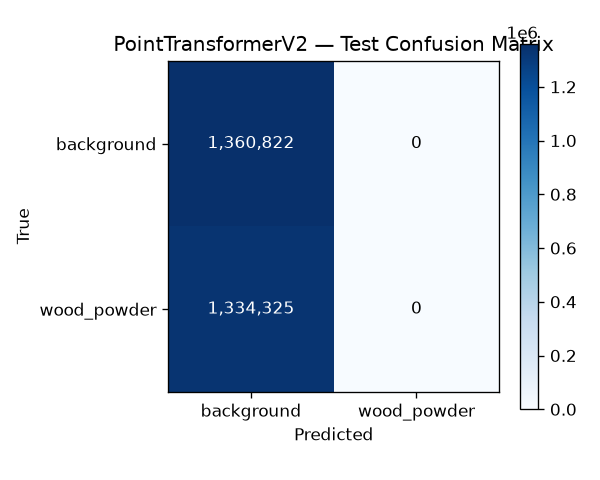

,file,iou,dice,precision,recall,tp,fp,fn,tn,gt_wood,pred_wood
0,sample_data_0045,0.0,0.0,0.0,0.0,0,0,221929,194215,221929,0
1,sample_data_0032,0.0,0.0,0.0,0.0,0,0,199206,181410,199206,0
2,sample_data_0033,0.0,0.0,0.0,0.0,0,0,215719,231565,215719,0
3,sample_data_008,0.0,0.0,0.0,0.0,0,0,282945,161187,282945,0
4,sample_data_0041,0.0,0.0,0.0,0.0,0,0,221863,144238,221863,0
5,sample_data_006,0.0,0.0,0.0,0.0,0,0,192663,448207,192663,0


2026-07-24 18:57:16,266 | INFO | predict_full_cloud: 416,144 points, N=8,192/chunk, batch=4, device=cuda — this can take a while on CPU, progress below


🏃 View run AL_random_r4_seg at: http://localhost:5000/#/experiments/16/runs/3d29202d4cb8488a935f4dc2ca70b1c8
🧪 View experiment at: http://localhost:5000/#/experiments/16


2026-07-24 18:57:16,634 | INFO |   flush 1: 32,768/416,144 pts covered (7.9%)
2026-07-24 18:57:16,927 | INFO |   flush 2: 61,392/416,144 pts covered (14.8%)
2026-07-24 18:57:17,219 | INFO |   flush 3: 92,076/416,144 pts covered (22.1%)
2026-07-24 18:57:17,512 | INFO |   flush 4: 119,741/416,144 pts covered (28.8%)
2026-07-24 18:57:17,808 | INFO |   flush 5: 146,779/416,144 pts covered (35.3%)
2026-07-24 18:57:18,112 | INFO |   flush 6: 174,953/416,144 pts covered (42.0%)
2026-07-24 18:57:18,404 | INFO |   flush 7: 201,167/416,144 pts covered (48.3%)
2026-07-24 18:57:18,705 | INFO |   flush 8: 224,175/416,144 pts covered (53.9%)
2026-07-24 18:57:18,994 | INFO |   flush 9: 244,759/416,144 pts covered (58.8%)
2026-07-24 18:57:19,310 | INFO |   flush 10: 265,585/416,144 pts covered (63.8%)
2026-07-24 18:57:19,609 | INFO |   flush 11: 290,717/416,144 pts covered (69.9%)
2026-07-24 18:57:19,897 | INFO |   flush 12: 312,605/416,144 pts covered (75.1%)
2026-07-24 18:57:20,200 | INFO |   flush 


───────────────────────────────────────────────────────
  File          : sample_data_0045
  Total Points  : 416,144
  Target Points : 0
  Other Points  : 416,144
  Target Ratio  : 0.00%
  Est. Volume   : nan m³
───────────────────────────────────────────────────────


...


───────────────────────────────────────────────────────
  File          : sample_data_0032
  Total Points  : 380,616
  Target Points : 0
  Other Points  : 380,616
  Target Ratio  : 0.00%
  Est. Volume   : nan m³
───────────────────────────────────────────────────────


2026-07-24 18:57:33,102 | INFO | predict_full_cloud: 447,284 points, N=8,192/chunk, batch=4, device=cuda — this can take a while on CPU, progress below


🏃 View run AL_random_r4_seg at: http://localhost:5000/#/experiments/16/runs/3d29202d4cb8488a935f4dc2ca70b1c8
🧪 View experiment at: http://localhost:5000/#/experiments/16


2026-07-24 18:57:33,466 | INFO |   flush 1: 32,768/447,284 pts covered (7.3%)
2026-07-24 18:57:33,754 | INFO |   flush 2: 65,331/447,284 pts covered (14.6%)
2026-07-24 18:57:34,050 | INFO |   flush 3: 93,544/447,284 pts covered (20.9%)
2026-07-24 18:57:34,348 | INFO |   flush 4: 125,870/447,284 pts covered (28.1%)
2026-07-24 18:57:34,672 | INFO |   flush 5: 150,665/447,284 pts covered (33.7%)
2026-07-24 18:57:35,001 | INFO |   flush 6: 177,711/447,284 pts covered (39.7%)
2026-07-24 18:57:35,321 | INFO |   flush 7: 197,414/447,284 pts covered (44.1%)
2026-07-24 18:57:35,614 | INFO |   flush 8: 225,585/447,284 pts covered (50.4%)
2026-07-24 18:57:35,910 | INFO |   flush 9: 246,281/447,284 pts covered (55.1%)
2026-07-24 18:57:36,197 | INFO |   flush 10: 270,608/447,284 pts covered (60.5%)
2026-07-24 18:57:36,496 | INFO |   flush 11: 288,353/447,284 pts covered (64.5%)
2026-07-24 18:57:36,805 | INFO |   flush 12: 308,808/447,284 pts covered (69.0%)
2026-07-24 18:57:37,148 | INFO |   flush 


───────────────────────────────────────────────────────
  File          : sample_data_0033
  Total Points  : 447,284
  Target Points : 0
  Other Points  : 447,284
  Target Ratio  : 0.00%
  Est. Volume   : nan m³
───────────────────────────────────────────────────────
🏃 View run AL_random_r4_seg at: http://localhost:5000/#/experiments/16/runs/3d29202d4cb8488a935f4dc2ca70b1c8
🧪 View experiment at: http://localhost:5000/#/experiments/16


In [25]:
log.info("=== TESTING ===")
test_names, test_true, test_pred = [], [], []
for path in TEST_FILES:
    name = os.path.splitext(os.path.basename(path))[0]
    pts, preds, lbl = predict_full_cloud(model, path)
    test_names.append(name); test_true.append(lbl); test_pred.append(preds)
per_file_report(test_names, test_true, test_pred, tag="TEST",
                target_class=CONFIG["target_class"])

if MLFLOW_OK and test_true and all(t is not None for t in test_true):
    from sklearn.metrics import classification_report
    _all_true = np.concatenate(test_true)
    _all_pred = np.concatenate(test_pred)
    _report_dict = classification_report(
        _all_true, _all_pred, target_names=["background", "wood_powder"],
        output_dict=True, zero_division=0)
    _report_text = classification_report(
        _all_true, _all_pred, target_names=["background", "wood_powder"],
        zero_division=0)
    log.info("=== TEST CLASSIFICATION REPORT ===\n" + _report_text)

    _test_miou = compute_miou(_all_true, _all_pred, NUM_CLASSES)
    _test_dice = compute_dice(_all_true, _all_pred, NUM_CLASSES)

    try:
        with mlflow.start_run(run_id=LAST_RUN_ID):
            mlflow.log_metrics({
                "test_accuracy"          : _report_dict["accuracy"],
                "test_miou"              : _test_miou,
                "test_dice"              : _test_dice,
                "test_precision_target"  : _report_dict["wood_powder"]["precision"],
                "test_recall_target"     : _report_dict["wood_powder"]["recall"],
                "test_f1_target"         : _report_dict["wood_powder"]["f1-score"],
                "test_precision_bg"      : _report_dict["background"]["precision"],
                "test_recall_bg"         : _report_dict["background"]["recall"],
                "test_f1_bg"             : _report_dict["background"]["f1-score"],
            })
            _report_path = os.path.join(CONFIG["checkpoint_dir"],
                                        f"{MODEL_NAME}_test_classification_report.txt")
            with open(_report_path, "w") as _f:
                _f.write(_report_text)
            mlflow.log_artifact(_report_path)

            import matplotlib
            matplotlib.use("Agg")
            import matplotlib.pyplot as _plt2
            from sklearn.metrics import confusion_matrix
            _cm = confusion_matrix(_all_true, _all_pred, labels=list(range(NUM_CLASSES)))
            _fig_cm, _ax_cm = _plt2.subplots(figsize=(5, 4))
            _im = _ax_cm.imshow(_cm, cmap="Blues")
            _ax_cm.set_xticks(range(NUM_CLASSES)); _ax_cm.set_yticks(range(NUM_CLASSES))
            _ax_cm.set_xticklabels(["background", "wood_powder"])
            _ax_cm.set_yticklabels(["background", "wood_powder"])
            _ax_cm.set_xlabel("Predicted"); _ax_cm.set_ylabel("True")
            _ax_cm.set_title(f"{MODEL_NAME} — Test Confusion Matrix")
            for _r in range(NUM_CLASSES):
                for _c in range(NUM_CLASSES):
                    _ax_cm.text(_c, _r, f"{_cm[_r, _c]:,}", ha="center", va="center",
                              color="white" if _cm[_r, _c] > _cm.max() / 2 else "black")
            _plt2.colorbar(_im, ax=_ax_cm)
            _plt2.tight_layout()
            _cm_path = os.path.join(CONFIG["checkpoint_dir"], f"{MODEL_NAME}_confusion_matrix.png")
            _plt2.savefig(_cm_path, dpi=120)
            _plt2.close(_fig_cm)
            mlflow.log_artifact(_cm_path)
            from IPython.display import Image as _IPyImage2, display as _ipy_display2
            _ipy_display2(_IPyImage2(filename=_cm_path))

            import csv as _csv
            _csv_path = os.path.join(CONFIG["checkpoint_dir"], f"{MODEL_NAME}_per_file_test_report.csv")
            with open(_csv_path, "w", newline="") as _f:
                _w = _csv.writer(_f)
                _w.writerow(["file", "iou", "dice", "precision", "recall",
                           "tp", "fp", "fn", "tn", "gt_wood", "pred_wood"])
                for _name, _true, _pred in zip(test_names, test_true, test_pred):
                    if _true is None:
                        continue
                    _tp = int(((_true == CONFIG["target_class"]) &
                              (_pred == CONFIG["target_class"])).sum())
                    _fp = int(((_true != CONFIG["target_class"]) &
                              (_pred == CONFIG["target_class"])).sum())
                    _fn = int(((_true == CONFIG["target_class"]) &
                              (_pred != CONFIG["target_class"])).sum())
                    _tn = int(((_true != CONFIG["target_class"]) &
                              (_pred != CONFIG["target_class"])).sum())
                    _iou = _tp / (_tp + _fp + _fn) if (_tp + _fp + _fn) > 0 else 0.0
                    _dice_v = (2 * _tp / (2 * _tp + _fp + _fn)
                              if (2 * _tp + _fp + _fn) > 0 else 0.0)
                    _prec_v = _tp / (_tp + _fp) if (_tp + _fp) > 0 else 0.0
                    _rec_v = _tp / (_tp + _fn) if (_tp + _fn) > 0 else 0.0
                    _gt_wood = int((_true == CONFIG["target_class"]).sum())
                    _pred_wood = int((_pred == CONFIG["target_class"]).sum())
                    _w.writerow([_name, f"{_iou:.4f}", f"{_dice_v:.4f}", f"{_prec_v:.4f}",
                               f"{_rec_v:.4f}", _tp, _fp, _fn, _tn, _gt_wood, _pred_wood])
            mlflow.log_artifact(_csv_path)
            import pandas as _pd
            _ipy_display2(_pd.read_csv(_csv_path))
    except Exception as _e:
        log.warning(f"Could not log test metrics to MLflow (run_id={LAST_RUN_ID}): {_e}")
for path in TEST_FILES[:CONFIG["max_vis_files"]]:
    name = os.path.splitext(os.path.basename(path))[0]
    pts, preds, _ = predict_full_cloud(model, path)
    target_pts   = pts[preds == CONFIG["target_class"]]
    volume, conf = vol_TIN(target_pts)
    n_tot = len(pts)
    n_tgt = len(target_pts)
    print(f"\n{'─'*55}")
    print(f"  File          : {name}")
    print(f"  Total Points  : {n_tot:,}")
    print(f"  Target Points : {n_tgt:,}")
    print(f"  Other Points  : {n_tot - n_tgt:,}")
    print(f"  Target Ratio  : {n_tgt / max(n_tot, 1) * 100:.2f}%")
    print(f"  Est. Volume   : {volume:.4f} m³")
    if conf:
        print(f"  95% CI        : [{conf['ci_low']:.4f} – {conf['ci_high']:.4f}] m³"
              f"  (±{conf['std']:.4f})")
    print(f"{'─'*55}")
    visualize_segmentation(pts, preds,
                           title=f"{MODEL_NAME} | {name} | V={volume:.4f} m³")
    if MLFLOW_OK:
        try:
            import matplotlib
            matplotlib.use("Agg")
            import matplotlib.pyplot as _plt3
            _fig_s = _plt3.figure(figsize=(6, 5))
            _ax_s = _fig_s.add_subplot(111)
            _sub_idx = (np.random.RandomState(0).choice(len(pts), 20000, replace=False)
                       if len(pts) > 20000 else np.arange(len(pts)))
            _colors = np.where(preds[_sub_idx] == CONFIG["target_class"], "green", "red")
            _ax_s.scatter(pts[_sub_idx, 0], pts[_sub_idx, 1], c=_colors, s=1, alpha=0.5)
            _ax_s.set_title(f"{MODEL_NAME} | {name} (top-down view)")
            _ax_s.set_xlabel("X"); _ax_s.set_ylabel("Y"); _ax_s.set_aspect("equal")
            _plt3.tight_layout()
            _sample_path = os.path.join(CONFIG["checkpoint_dir"], f"{MODEL_NAME}_{name}_sample.png")
            _plt3.savefig(_sample_path, dpi=100)
            _plt3.close(_fig_s)
            with mlflow.start_run(run_id=LAST_RUN_ID):
                mlflow.log_artifact(_sample_path)
        except Exception as _e:
            log.warning(f"Could not log sample visualization for {name}: {_e}")

## Final Inference  (`data/test`, no labels)

In [26]:
if INFER_FILES:
    log.info("=== FINAL INFERENCE ===")
    infer_names, infer_true, infer_pred, infer_pts = [], [], [], []
    for path in INFER_FILES:
        name = os.path.splitext(os.path.basename(path))[0]
        pts, preds, lbl = predict_full_cloud(model, path)
        infer_names.append(name)
        infer_true.append(lbl if lbl is not None and lbl.any() else None)
        infer_pred.append(preds)
        infer_pts.append(pts)
    per_file_report(infer_names, infer_true, infer_pred, tag="INFERENCE",
                    target_class=CONFIG["target_class"])
    for name, pts, preds in zip(infer_names, infer_pts, infer_pred):
        target_pts   = pts[preds == CONFIG["target_class"]]
        volume, conf = vol_TIN(target_pts)
        n_tot = len(pts)
        n_tgt = len(target_pts)
        print(f"\n{'─'*55}")
        print(f"  File          : {name}")
        print(f"  Total Points  : {n_tot:,}")
        print(f"  Target Points : {n_tgt:,}")
        print(f"  Other Points  : {n_tot - n_tgt:,}")
        print(f"  Target Ratio  : {n_tgt / max(n_tot, 1) * 100:.2f}%")
        print(f"  Est. Volume   : {volume:.4f} m³")
        if conf:
            print(f"  95% CI        : [{conf['ci_low']:.4f} – {conf['ci_high']:.4f}] m³"
                  f"  (±{conf['std']:.4f})")
        print(f"{'─'*55}")
        visualize_segmentation(pts, preds,
                               title=f"INFERENCE | {MODEL_NAME} | {name} | "
                                     f"V={volume:.4f} m³")
else:
    log.info("data/test is empty — skipping inference.")

2026-07-24 18:57:42,580 | INFO | === FINAL INFERENCE ===
2026-07-24 18:57:42,753 | INFO | predict_full_cloud: 461,841 points, N=8,192/chunk, batch=4, device=cuda — this can take a while on CPU, progress below
2026-07-24 18:57:43,142 | INFO |   flush 1: 32,768/461,841 pts covered (7.1%)
2026-07-24 18:57:43,451 | INFO |   flush 2: 64,567/461,841 pts covered (14.0%)
2026-07-24 18:57:43,718 | INFO |   flush 3: 93,194/461,841 pts covered (20.2%)
2026-07-24 18:57:44,002 | INFO |   flush 4: 122,400/461,841 pts covered (26.5%)
2026-07-24 18:57:44,286 | INFO |   flush 5: 150,536/461,841 pts covered (32.6%)
2026-07-24 18:57:44,580 | INFO |   flush 6: 179,847/461,841 pts covered (38.9%)
2026-07-24 18:57:44,856 | INFO |   flush 7: 207,516/461,841 pts covered (44.9%)
2026-07-24 18:57:45,162 | INFO |   flush 8: 227,026/461,841 pts covered (49.2%)
2026-07-24 18:57:45,458 | INFO |   flush 9: 254,939/461,841 pts covered (55.2%)
2026-07-24 18:57:45,766 | INFO |   flush 10: 272,363/461,841 pts covered (5


PER-FILE SEGMENTATION REPORT — INFERENCE
File                      IoU   Dice   Prec    Rec       TP       FP       FN       TN   GT_Wood  Pred_Wood
-----------------------------------------------------------------------------------------------------------
sample_data_0046            —      —      —      —        —        —        —        —         —          0
sample_data_0047            —      —      —      —        —        —        —        —         —          0
sample_data_0048            —      —      —      —        —        —        —        —         —          0
sample_data_0049            —      —      —      —        —        —        —        —         —          0
sample_data_0050            —      —      —      —        —        —        —        —         —          0
sample_data_0051            —      —      —      —        —        —        —        —         —          0
sample_data_0052            —      —      —      —        —        —        —        —        

In [27]:
import torch
torch.version.cuda

'12.1'